<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS2 - Modelizando un ADC*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Introducción teórica**</u>

Un conversor analógico - digital (ADC) actúa como un puente entre el mundo analógico, caracterizado por señales continuas en el tiempo, y el mundo digital, basado en secuencias discretas de valores binarios. Para que los sistemas digitales puedan procesar señales analógicas, es necesario convertir dichas señales a formato digital de manera precisa y consistente. 

El proceso de conversión llevado a cabo por un ADC involucra principalmente dos etapas: 

- Muestreo: Consiste en tomar valores de la señal analógica en instantes discretos de tiempo, determinados por la frecuencia de muestreo ($f_{s}$).
- Cuantización: Implica discretizar los valores de amplitud de la señal, asignando cada muestra al nivel más cercano dentro de un conjunto finito de valores definidos por la resolución de *B* bits.

La cuantización introduce una pérdida irreversible de información. Este error se manifiesta como ruido de cuantización, el cual se modela como una señal aleatoria de media nula ($\mu = 0$). 

La potencia de este ruido está dada por:
$$P_{q} = \frac{q^2}{12}$$
donde $q = \frac{2 \cdot V_{cc}}{2^B} = \frac{V_{cc}}{2^{B - 1}}$ es el paso de cuantización, el cual está determinado por el rango analógico del ADC ($\pm V_{F}$, define los límites máximos y mínimos de la señal que puede representarse sin saturación) y la cantidad de bits *B*, que fija el número de niveles disponibles $2^B$.

En este trabajo, la señal de entrada $s_{R}$ es de carácter aditivo: $s_{R} = s + n$

- La señal (*s*): es una senoidal con energia normalizada (varianza unitaria, $P_{s} = 1$) y frecuencia $f_{0}$.
- El ruido aditivo (*n*): representa la interferencia externa antes de la cuantización. Se define como un proceso gaussiano e incorrelado (ruido blanco), lo que significa que ss muestras son independientes entre si y su densidad de probabilidad sigue una campana de Gauss de media nula. Su potencia será $P_{n} = k_{n} \cdot P_{q}$ siendo $k_{n}$ una escala.

La combinación de estos factores define el piso de ruido del sistema. El ruido total presente en la señal digitalizada será la suma de la interferencia externa (*n*) y el error propio de cuantización (*q*). Este piso de ruido limita la capacidad de detectar señales de baja amplitud, ya que cualquier componente por debajo de este nivel queda *"tapado"* por el ruido.

Finalmente, la precisión real del sistema puede evaluarse mediante el ENOB (Effective Number of Bits). Este parámetro permite comparar el rendimiento del ADC real (afectado por el ruido aditivo *n* y la cunatización) con un ADC ideal, determinando cuántos bits de resolución son efectivamente aprovechables ante la presencia de distorsiones y ruido. A mayor cantidad de bits, mayor cantidad de niveles de cuantización y mejor representación de la señal. 

# <u>**Análisis y desarrollo**</u>

<u>**Item a**</u>

En esta primera parte del experimento, se generó una señal senoidal con potencia unitaria ($s$). Dado que la señal senoidal tiene potencia unitaria, y para una senoidal $P = \frac {A^2}{2}$, se obtiene una amplitud $A = \sqrt {2} = V_{max}$. Al mismo tiempo, se definieron los siguientes parámetros de la señal:

- Frecuencia de muestreo: $f_{s} = 1000 \; Hz$
- Cantidad de muestras: $N = 1000 \; \text {muestras}$
- Frecuencia de la señal: $f_{0} = \frac{f_{s}}{N} = \Delta f$
- Tiempo de muestreo: $T_{s} = \frac {1}{f_s}$
- Vector de tiempo: $tt$

Luego, se determinaron los parámetros del *ADC*:

- Número de bits: $B = 4$
- Rango del ADC: $\pm V_{F} = 2 \; V$
- Paso de cuantización: $q = \frac {2 \cdot V_{F}}{2^B}$
- Potencia de cuantización: $P_{q} = \frac {q^2}{12}$

Seguido a eso se definió el ruido de entrada ($n$), el cual se modela como una secuencia gaussiana, de media nula ($\mu = 0$) e incorrelado. Se determinaron sus parámetros: 
- Factor de escala para la potencia del ruido de cuantización: $k_{n} = 1$
- Potencia del ruido: $P_{n} = k_{n} \cdot P_{q}$

Entonces, con todo esto se pudo determinar la señal senoidal con ruido: 
$$s_{r} = s + n$$
En el código es...
$$s_{r} = xx + U_n$$
donde $xx$ es la senoidal y $U_n$ el ruido blanco incorrelado.

Y por otro lado, se realizó la cuantización del *ADC*, utilizando la función de numpy *round* ($np.round(\frac {s_{r}}{q}) \cdot q)$.

In [11]:
#%% LLamo a las librerias que se van a utilizar
import numpy as np
import matplotlib.pyplot as plt

#%% Item a
# Defino los parámetros a utilizar
fs = 1000          # Hz
n = 1000           # muestras
f0 = fs / n        # Hz
ts = 1/fs
tt = np.arange(n) * ts

# Señal (potencia unitaria)
vmax = np.sqrt(2)
dc = 0
xx = dc + vmax * np.sin(2*np.pi*f0*tt)

#%% ADC 
B = 4
VF = 2  # rango +-2V
q = (2*VF) / (2**B)   # paso de cuantización
Pq = (q**2) / 12      # potencia de cuantización

# Defino el ruido
kn = 1
Pn = kn * Pq
mu = 0
U_n = np.random.normal(mu, np.sqrt(Pn), n)

# Señal con ruido
sr = xx + U_n

# Cuantización (ADC)
sq = np.round(sr / q) * q

Luego, se analizó el comportamiento espectral de la señal de salida del *ADC* ($s_{q}$) y también se analizaron las características del error de cuantización. 

Primero se calculó la Transformada Discreta de Fourier *DFT* (en código es la *FFT*) de las tres señales: la señal analógica original $xx$, la señal de entrada del *ADC* $s_r$ (la cual incluye el ruido) y la señal cuantizada $s_{q}$. A partir de las transformadas se obtuvo el módulo normalizado de cada espectro y se expresó en escala logarítmica (*dB*). Esto permite obtener una mejor visualización de los niveles de potencia y los niveles del ruido. 

Luego se construyó el eje de frecuencias utilizando la frecuencia de muestreo, y se consideró únicamente la mitad positiva del espectro, ya que la *FFT* de señales reales es simétrica. 

Por otro lado, se calcularon los pisos de ruido teóricos, tanto el analógico como el digital. El piso analógico está asociado al ruido presente en la señal de entrada, mientras que el piso digital está determinado por el ruido de cuantización introducido por el *ADC*. Estos pisos de ruido se representan en el gráfico del espectro de la *FFT* como líneas horizontales de referencia, permitiendo comparar visualmente el impacto de cada uno de los pisos de ruido sobre el espectro de la señal. 

Además, se evaluó el error de cuantización, el cual puede modelarse como uniforme ($e_{q} \sim U(\frac {-q}{2}, \frac {q}{2})$), y se define como la diferencia entre la señal cuantizada y la señal de entrada del *ADC* ($e_{q} = s_{q} - s_{r}$). Este error representa la distorsión introducida por el proceso de discretización. 

Finalmente, se graficaron tres figuras distintas para analizar los resultados: 

1) Señales en el dominio temporal: Se comparan la señal original, la señal de entrada al *ADC* (con ruido) y la señal cuantizada; esto permitió observar el efecto de la cuantización.
2) Espectro en frecuencia: Se representan los espectros en dB de la señal de entrada y la señal cuantizada, junto con ambos pisos de ruido teóricos (analógico y digital).
3) Histograma del error de cuantización: Se analiza la distribución estadística del error, la cual teóricamente es uniforme en el intervalo $[\frac {-q}{2}, \frac {q}{2}]$. Se incluyeron líneas de referencia que indican estos límites y la densidad teórica $\frac {1}{q}$, lo que permite verificar experimentalmente el comportamiento uniforme del histograma. 

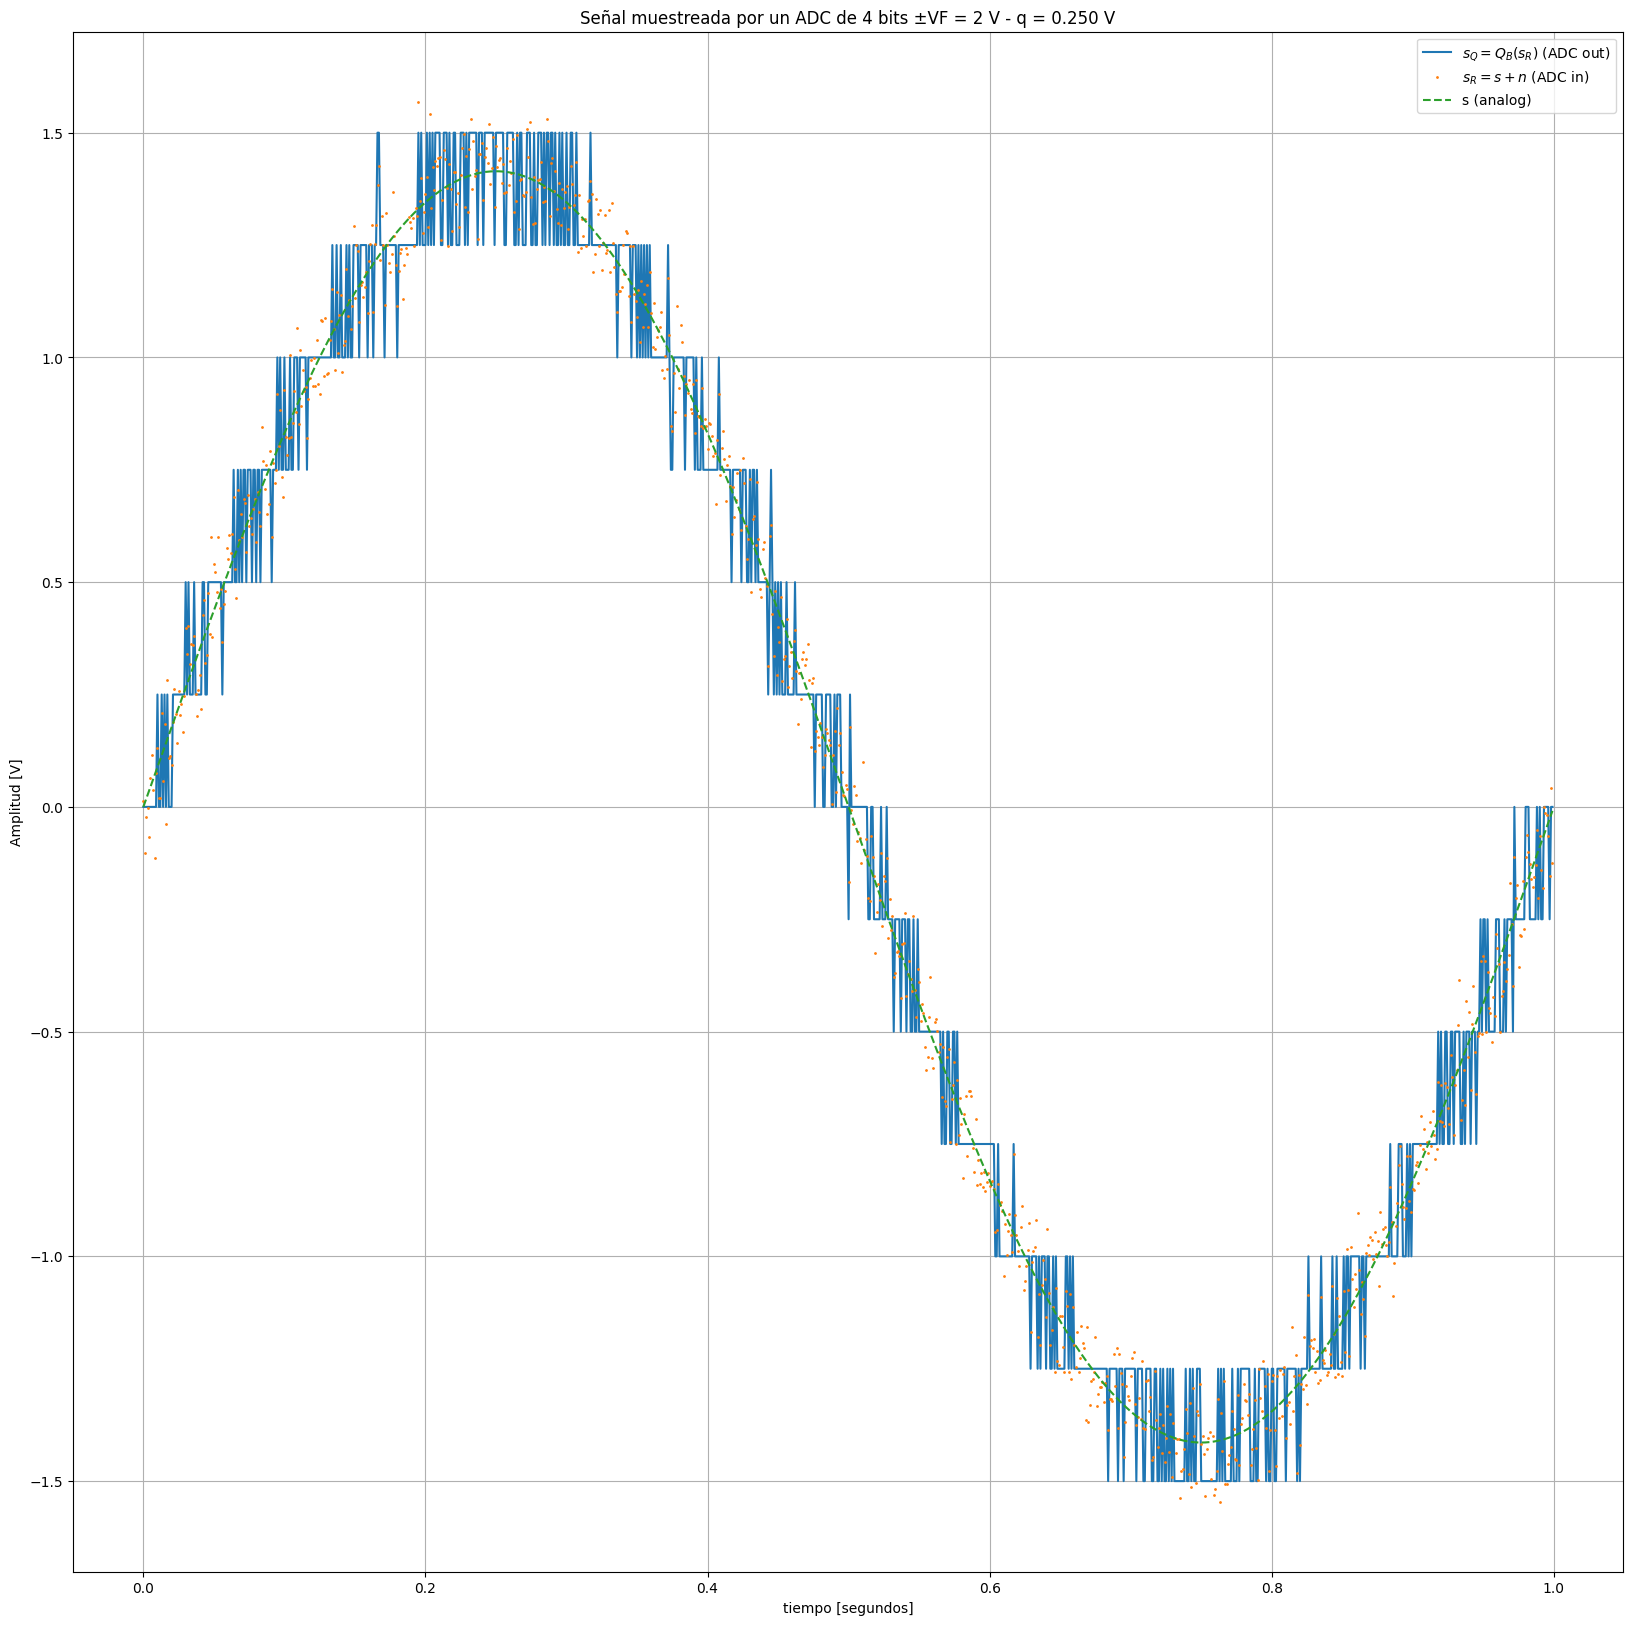

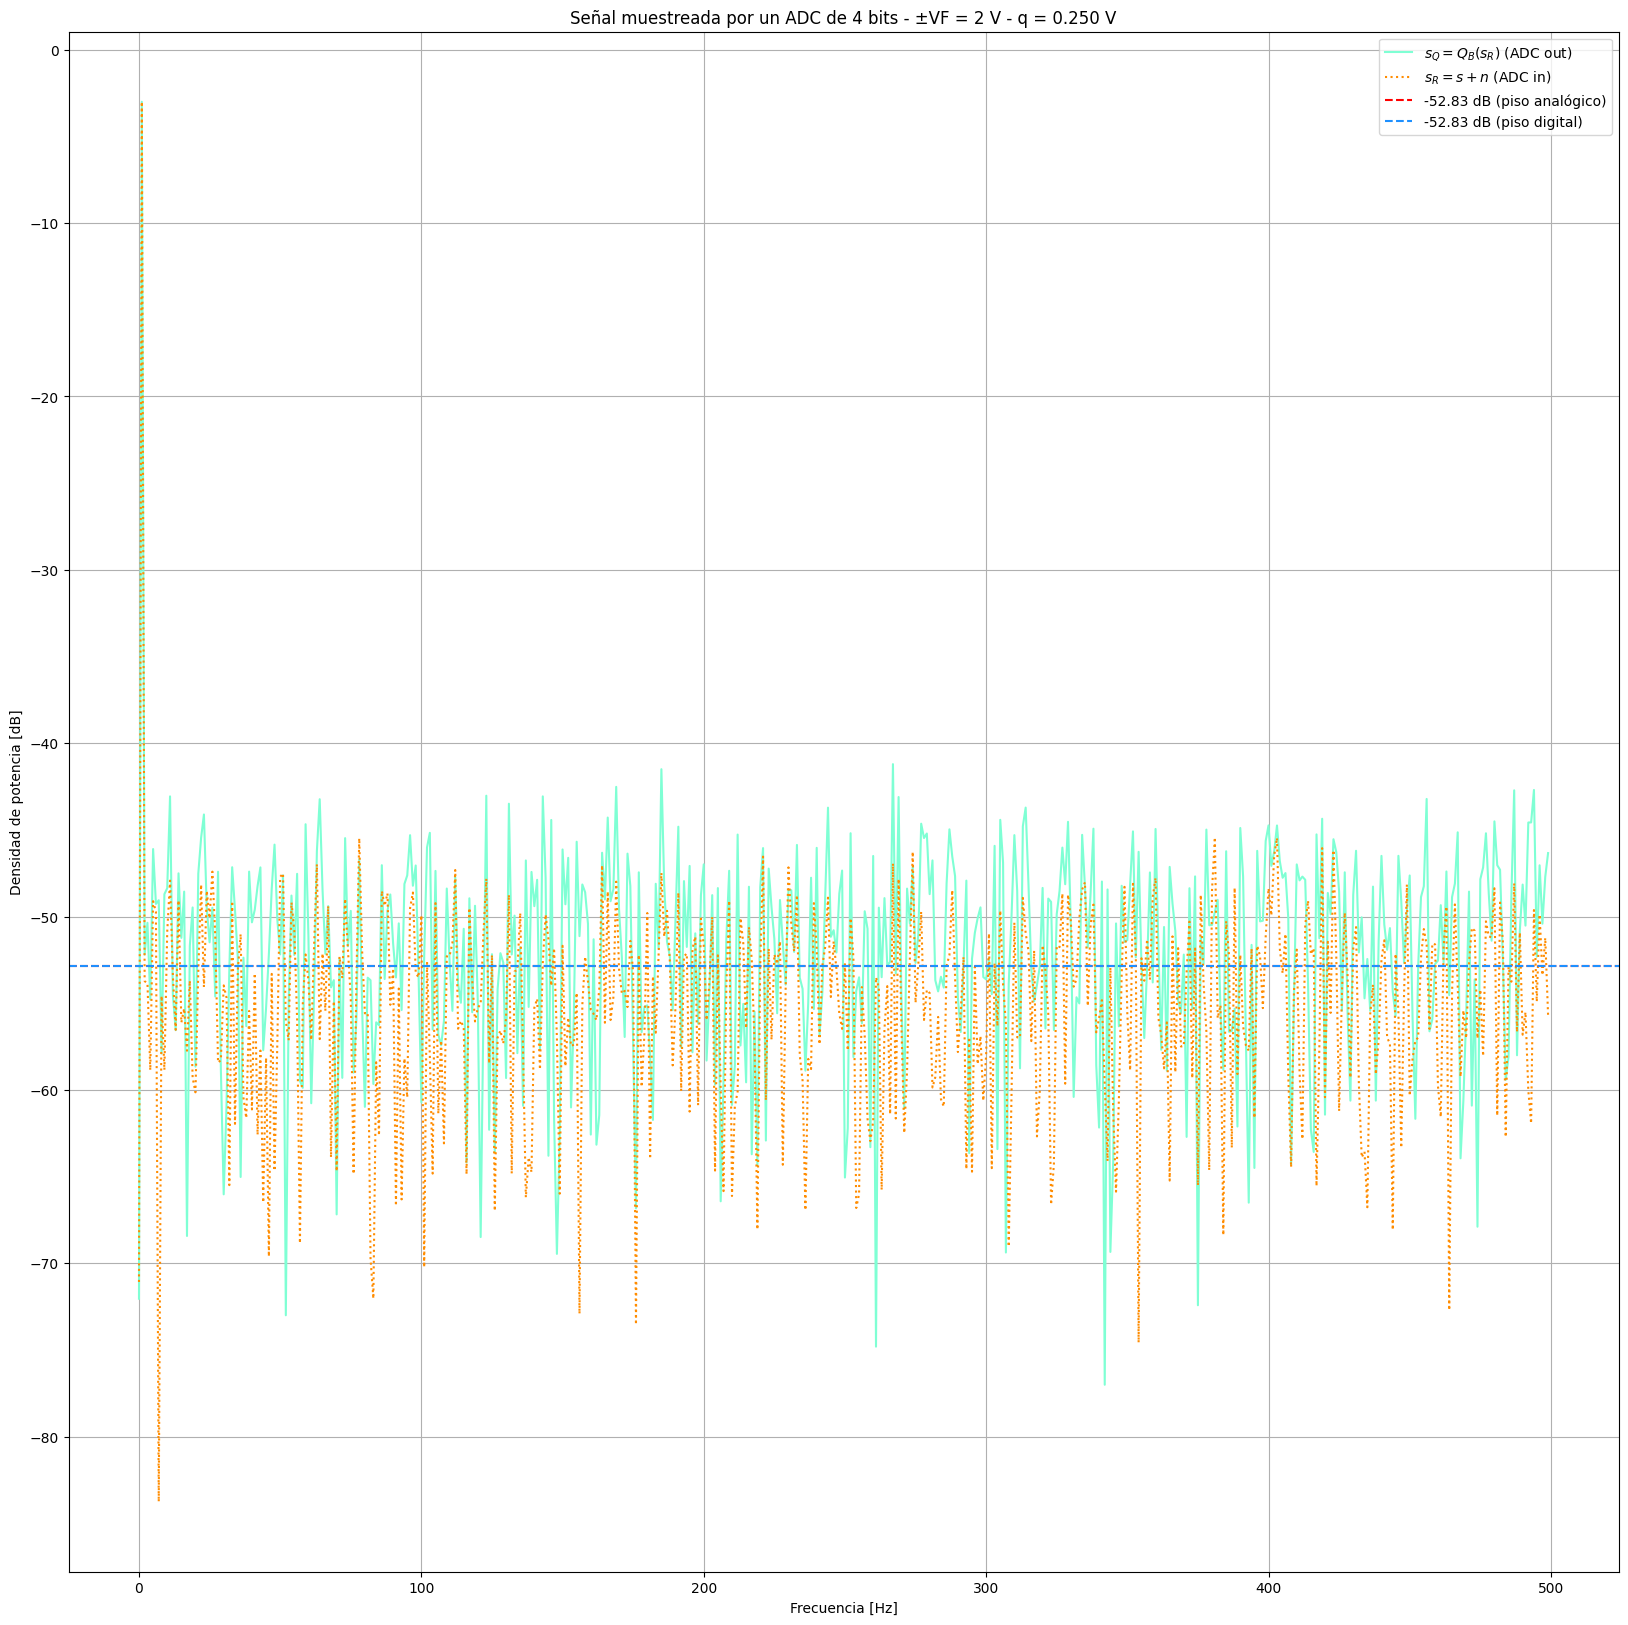

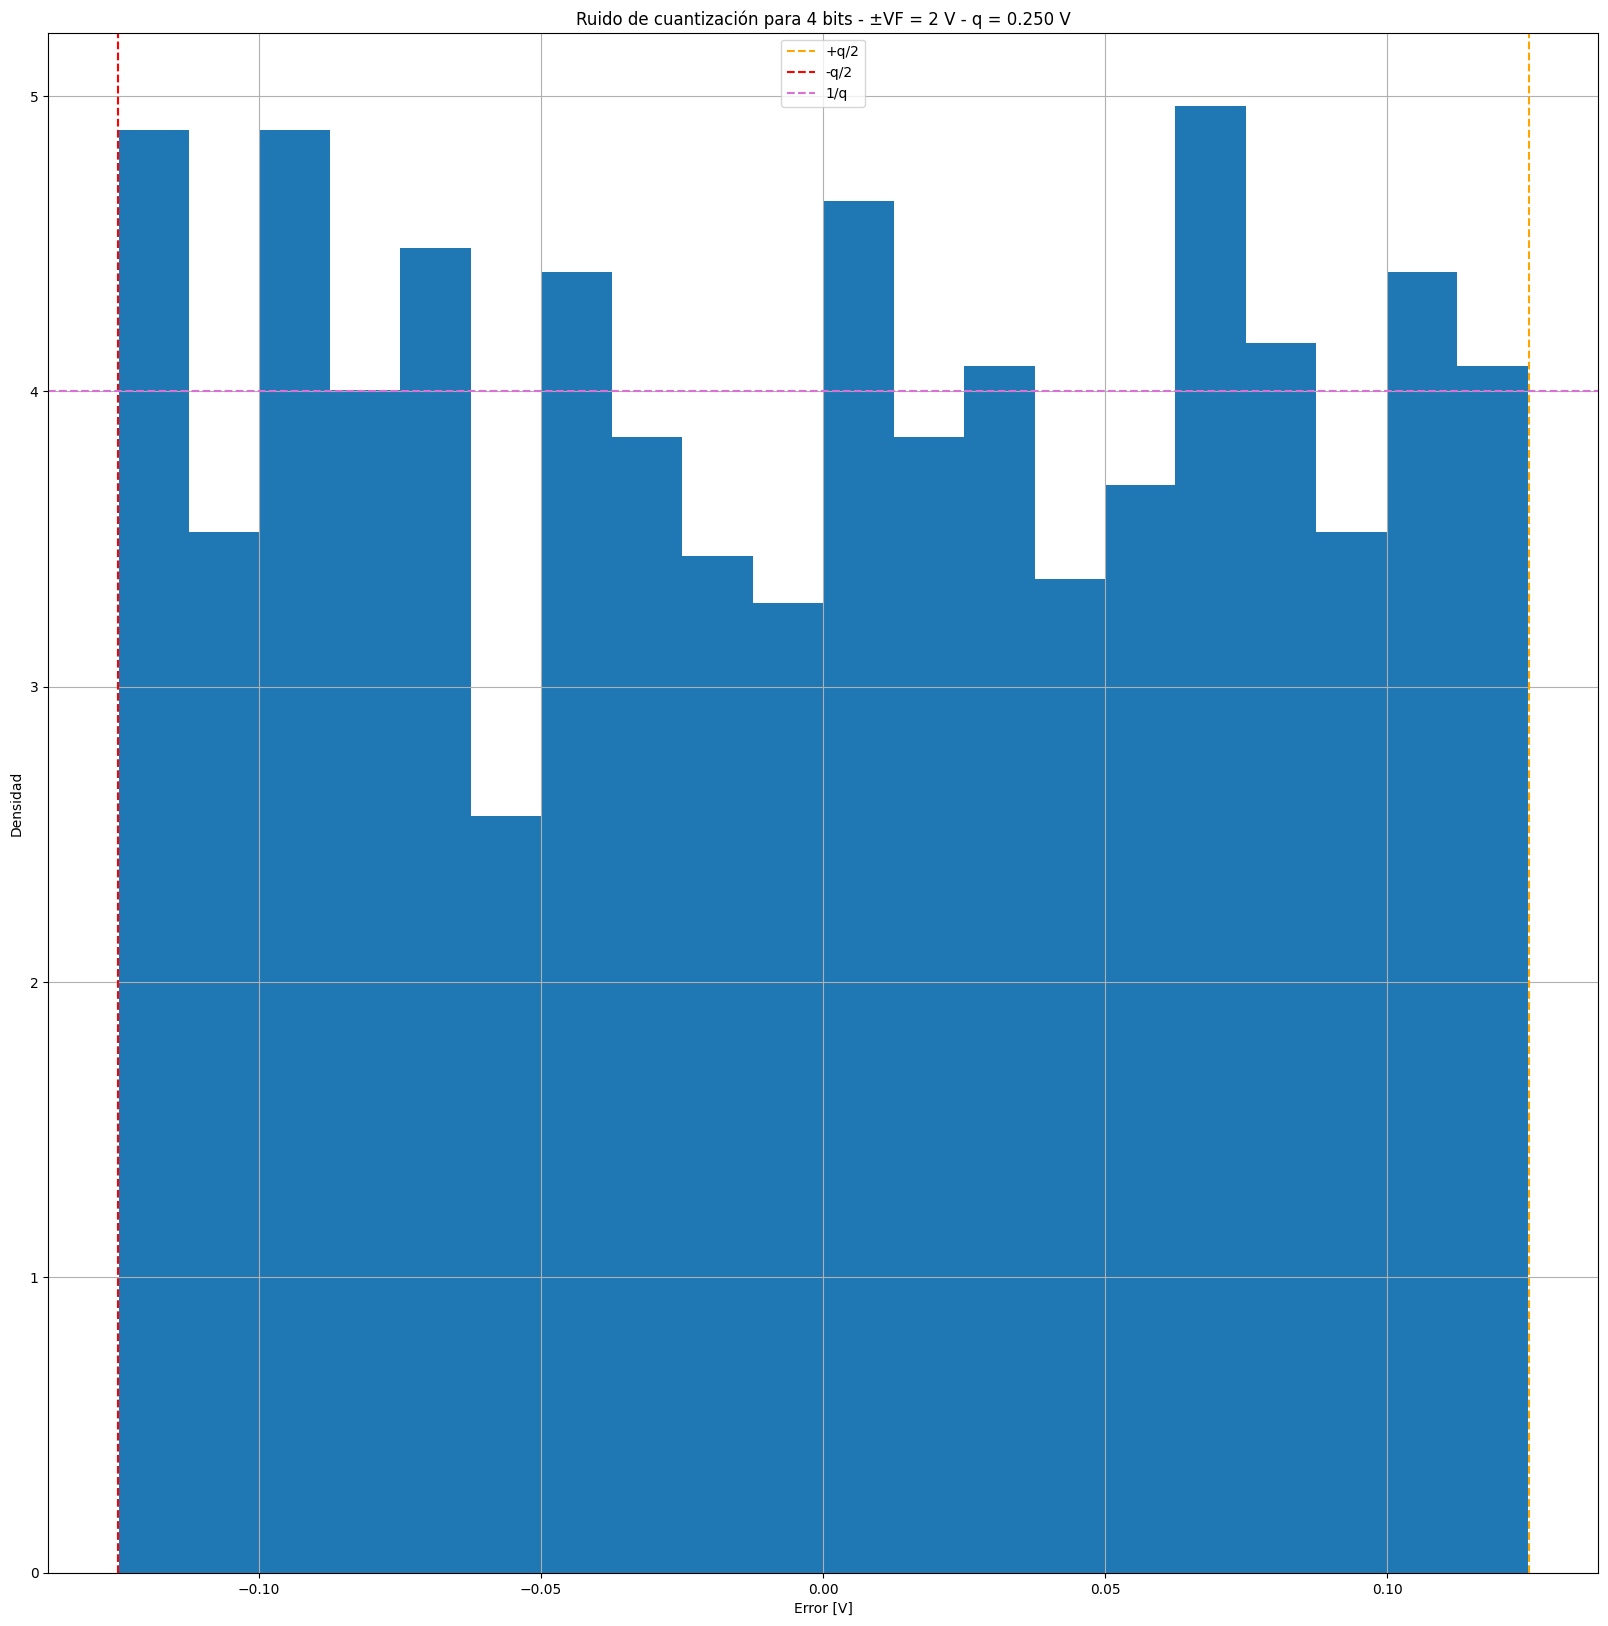

In [12]:
#%% FFT

N = len(xx)

# Señal pura
XX = np.fft.fft(xx)
XXmod = np.abs(XX) / N
XXmod_db = 20 * np.log10(XXmod + 1e-12)

# Señal con ruido (entrada ADC)
SR = np.fft.fft(sr)
SRmod = np.abs(SR) / N
SRmod_db = 20 * np.log10(SRmod + 1e-12)

# Señal cuantizada (salida ADC)
SQ = np.fft.fft(sq)
SQmod = np.abs(SQ) / N
SQmod_db = 20 * np.log10(SQmod + 1e-12)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, d=ts)

# Me quedo con la mitad positiva (eso es porque grafico el modulo)
mitad = N // 2
freqs = freqs[:mitad]

XXmod_db = XXmod_db[:mitad]
SRmod_db = SRmod_db[:mitad]
SQmod_db = SQmod_db[:mitad]

# Pisos teóricos
piso_analog = 10 * np.log10(Pn / (n))
piso_digital = 10 * np.log10(Pq / (n))

#%% Error de cuantización
e = sq - sr

#%% Graficos

# Entrada y salida del ADC
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(tt, sq, label=r'$s_Q = Q_B(s_R)$ (ADC out)')
plt.plot(tt, sr, '.', markersize=2, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt, xx, '--', label='s (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid()
plt.legend()
plt.show()


# Espectro de la FFT
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(freqs, SQmod_db, color = 'aquamarine', label=r'$s_Q = Q_B(s_R)$ (ADC out)')
# plt.plot(freqs, XXmod_db, color = 'forestgreen', label='s (analog)')
plt.plot(freqs, SRmod_db, ':', color = 'darkorange', label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analog, linestyle='--', color = 'red', label=f'{piso_analog:.2f} dB (piso analógico)')
plt.axhline(piso_digital, linestyle='--', color = 'dodgerblue', label=f'{piso_digital:.2f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF} V - q = {q:.3f} V')

plt.grid()
plt.legend()
plt.show()


# Histograma del error de cuantizacion
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.hist(e, bins=20, density=True)

plt.axvline(q/2, linestyle='--', color='orange', label='+q/2')
plt.axvline(-q/2, linestyle='--', color = 'red', label='-q/2')
plt.axhline(1/q, linestyle='--', color = 'orchid', label='1/q')

plt.title(f'Ruido de cuantización para {B} bits - ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')

plt.grid()
plt.legend()
plt.show()

b) 4 Bits y K = 1/10

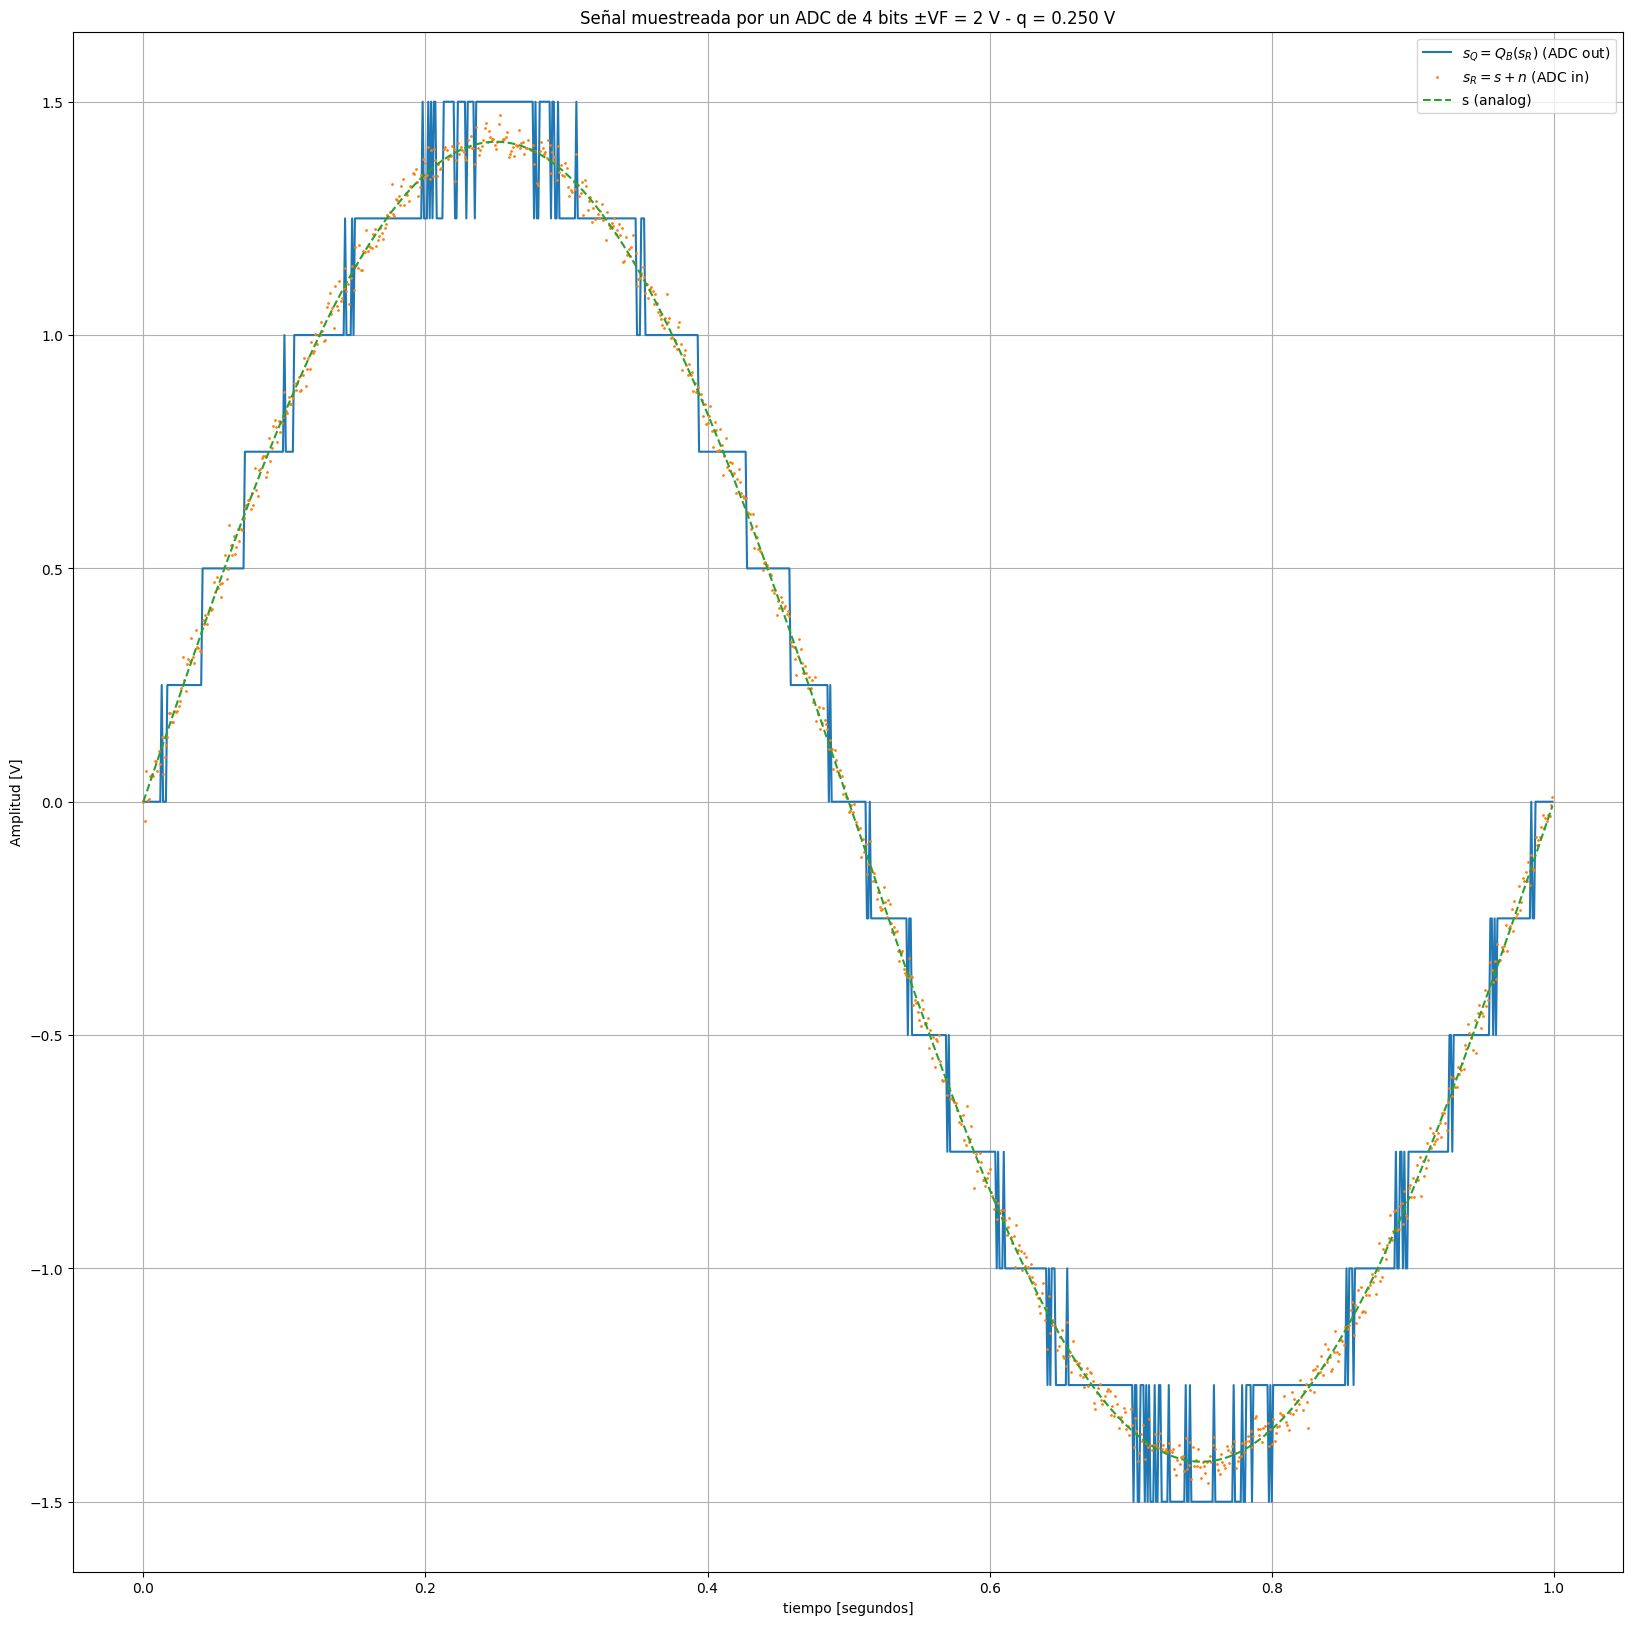

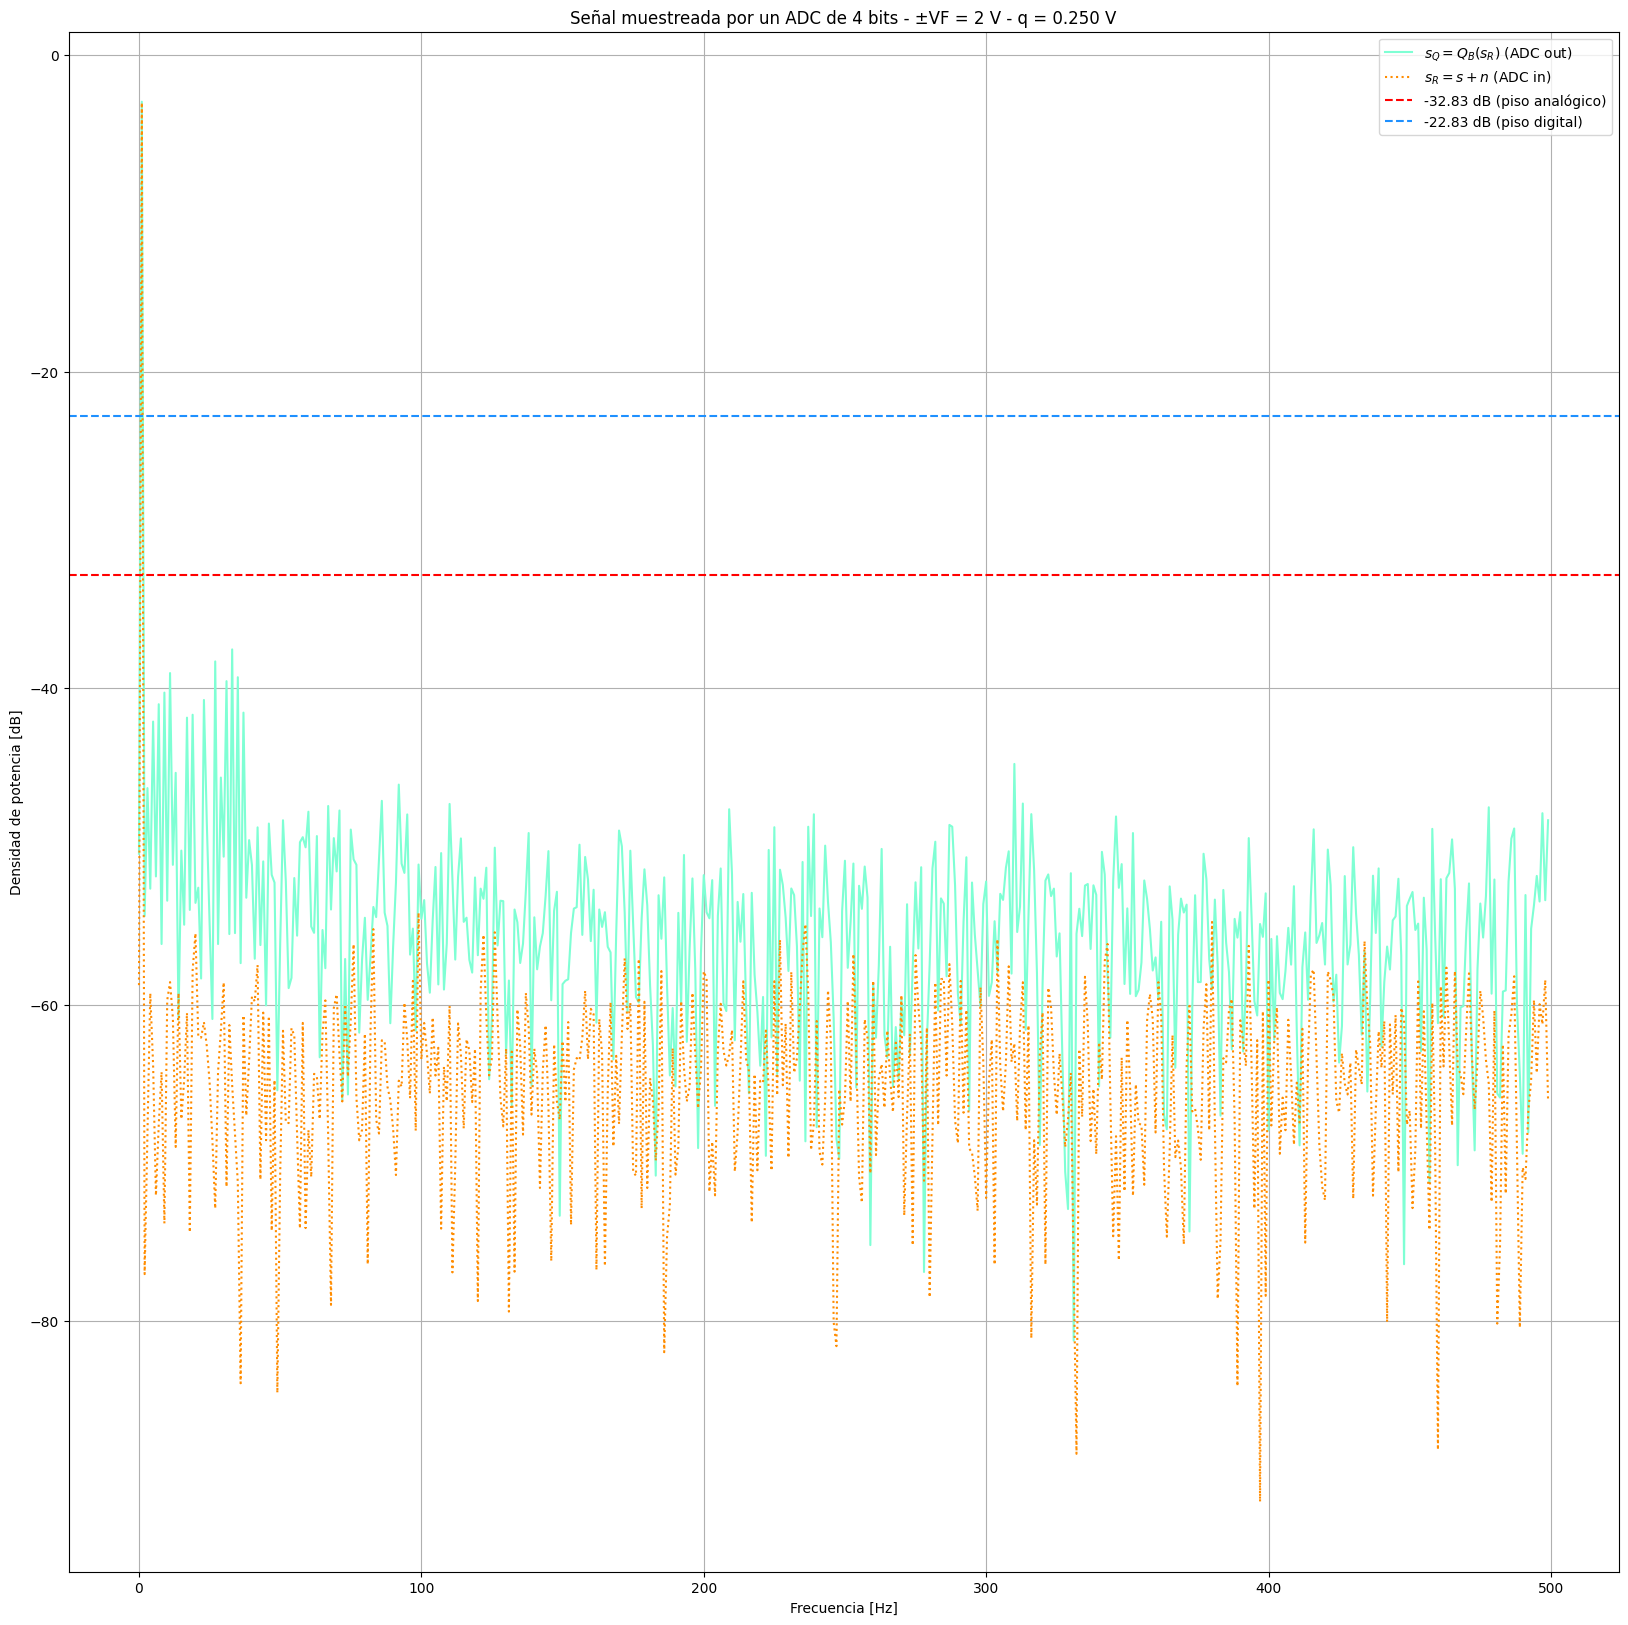

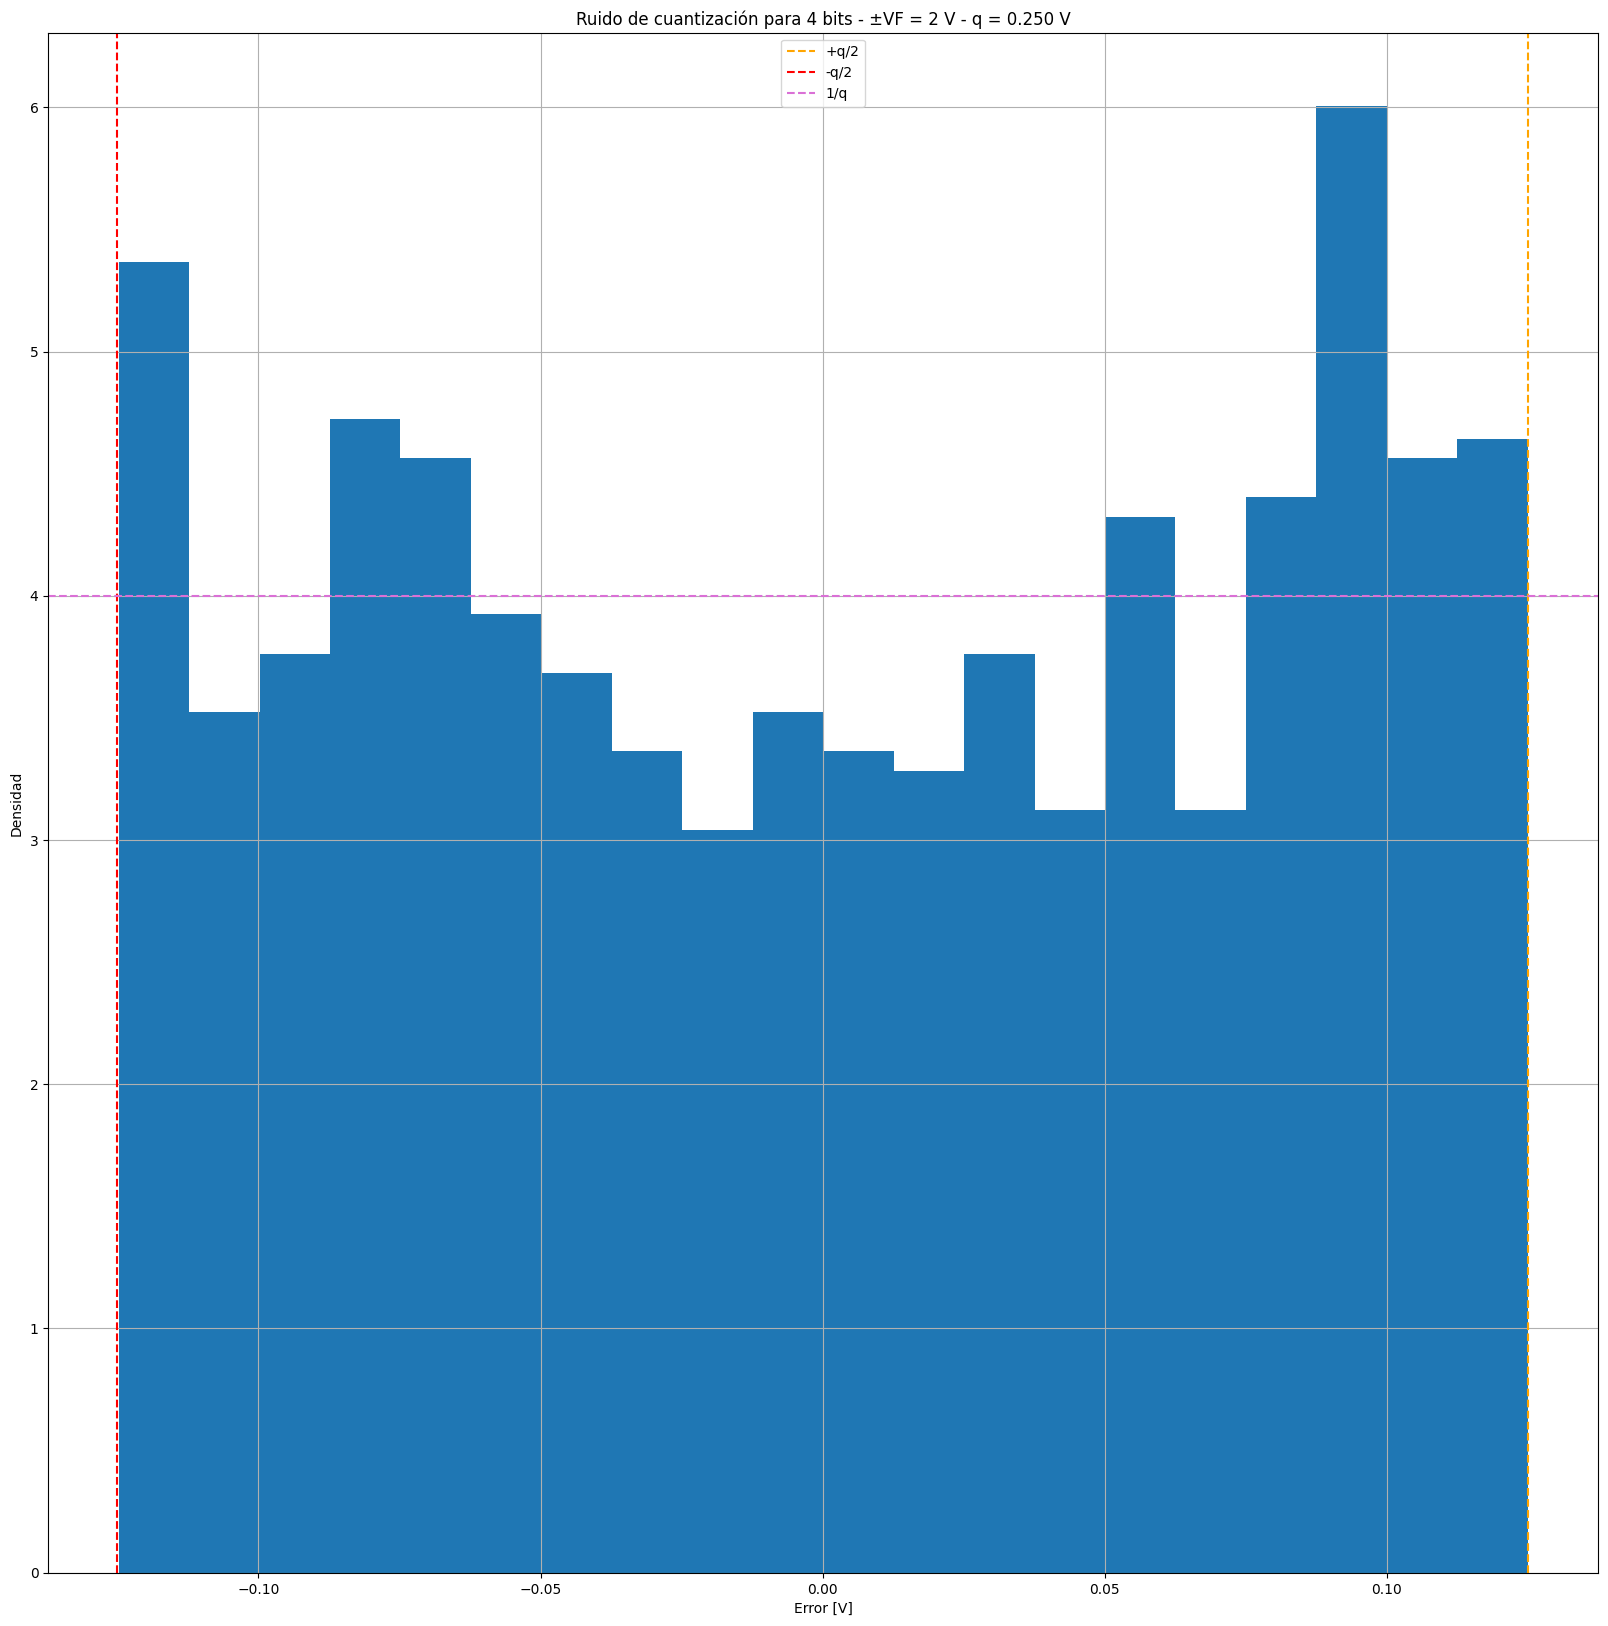

In [13]:
#%% ADC (4 bits y k = 1/10)
# Defino el ruido
kn = 1/10
Pn = kn * Pq
mu = 0
U_n = np.random.normal(mu, np.sqrt(Pn), n)

# Señal con ruido
sr = xx + U_n

# Cuantización (ADC)
sq = np.round(sr / q) * q

#%% FFT

N = len(xx)

# Señal pura
XX = np.fft.fft(xx)
XXmod = np.abs(XX) / N
XXmod_db = 20 * np.log10(XXmod + 1e-12)

# Señal con ruido (entrada ADC)
SR = np.fft.fft(sr)
SRmod = np.abs(SR) / N
SRmod_db = 20 * np.log10(SRmod + 1e-12)

# Señal cuantizada (salida ADC)
SQ = np.fft.fft(sq)
SQmod = np.abs(SQ) / N
SQmod_db = 20 * np.log10(SQmod + 1e-12)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, d=ts)

# Me quedo con la mitad positiva (eso es porque grafico el modulo)
mitad = N // 2
freqs = freqs[:mitad]

XXmod_db = XXmod_db[:mitad]
SRmod_db = SRmod_db[:mitad]
SQmod_db = SQmod_db[:mitad]

# Pisos teóricos
piso_analog = 10 * np.log10(Pn)
piso_digital = 10 * np.log10(Pq)

#%% Error de cuantización
e = sq - sr

#%% Graficos

# Entrada y salida del ADC
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(tt, sq, label=r'$s_Q = Q_B(s_R)$ (ADC out)')
plt.plot(tt, sr, '.', markersize=2, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt, xx, '--', label='s (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid()
plt.legend()
plt.show()


# Espectro de la FFT
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(freqs, SQmod_db, color = 'aquamarine', label=r'$s_Q = Q_B(s_R)$ (ADC out)')
# plt.plot(freqs, XXmod_db, color = 'forestgreen', label='s (analog)')
plt.plot(freqs, SRmod_db, ':', color = 'darkorange', label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analog, linestyle='--', color = 'red', label=f'{piso_analog:.2f} dB (piso analógico)')
plt.axhline(piso_digital, linestyle='--', color = 'dodgerblue', label=f'{piso_digital:.2f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF} V - q = {q:.3f} V')

plt.grid()
plt.legend()
plt.show()


# Histograma del error de cuantizacion
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.hist(e, bins=20, density=True)

plt.axvline(q/2, linestyle='--', color='orange', label='+q/2')
plt.axvline(-q/2, linestyle='--', color = 'red', label='-q/2')
plt.axhline(1/q, linestyle='--', color = 'orchid', label='1/q')

plt.title(f'Ruido de cuantización para {B} bits - ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')

plt.grid()
plt.legend()
plt.show()

8 Bits y K = 1

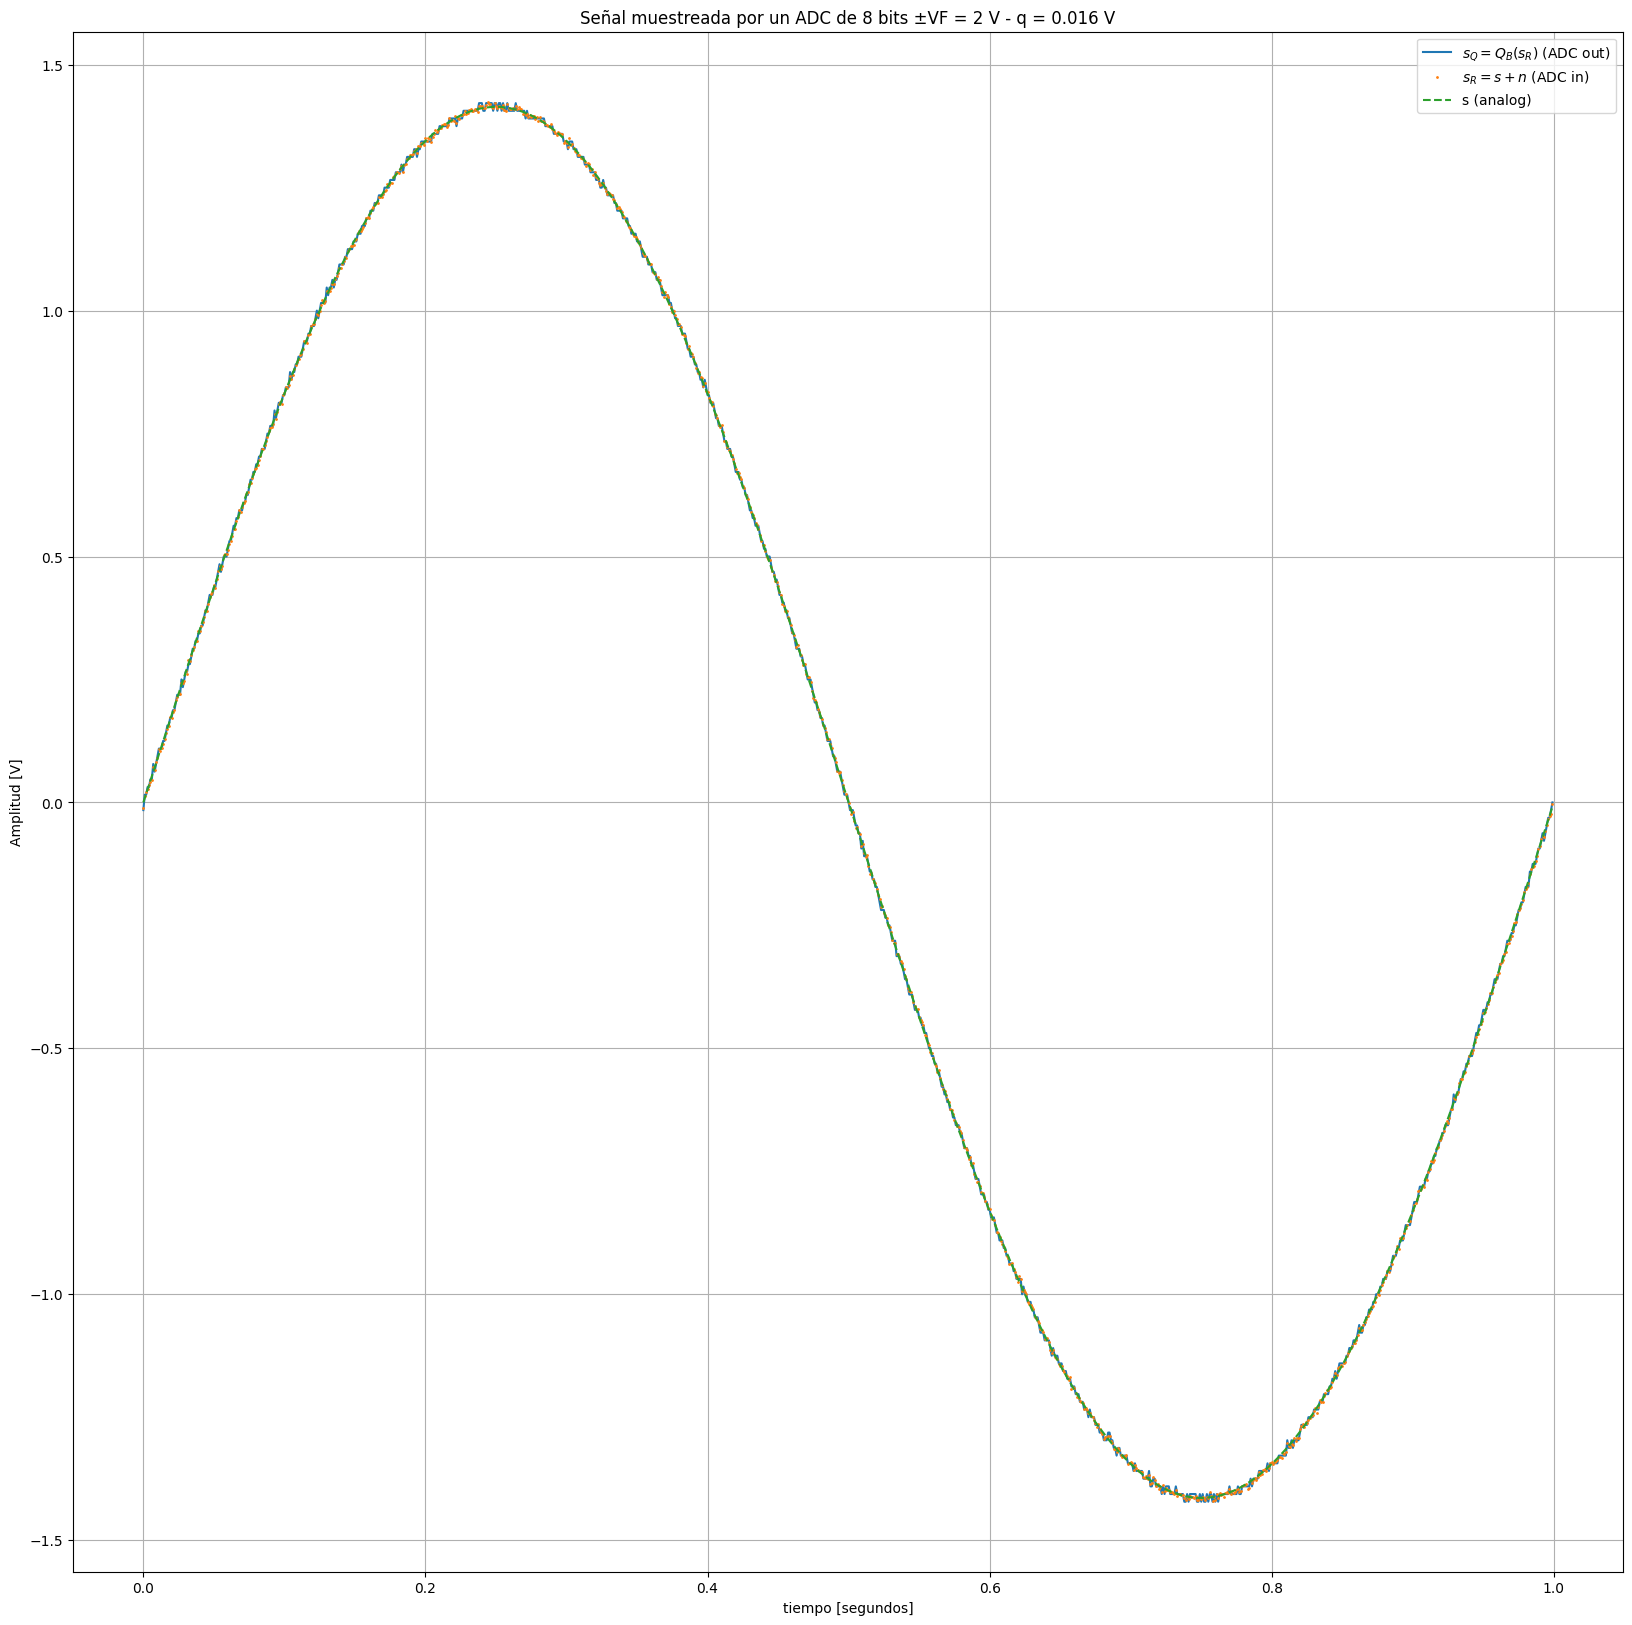

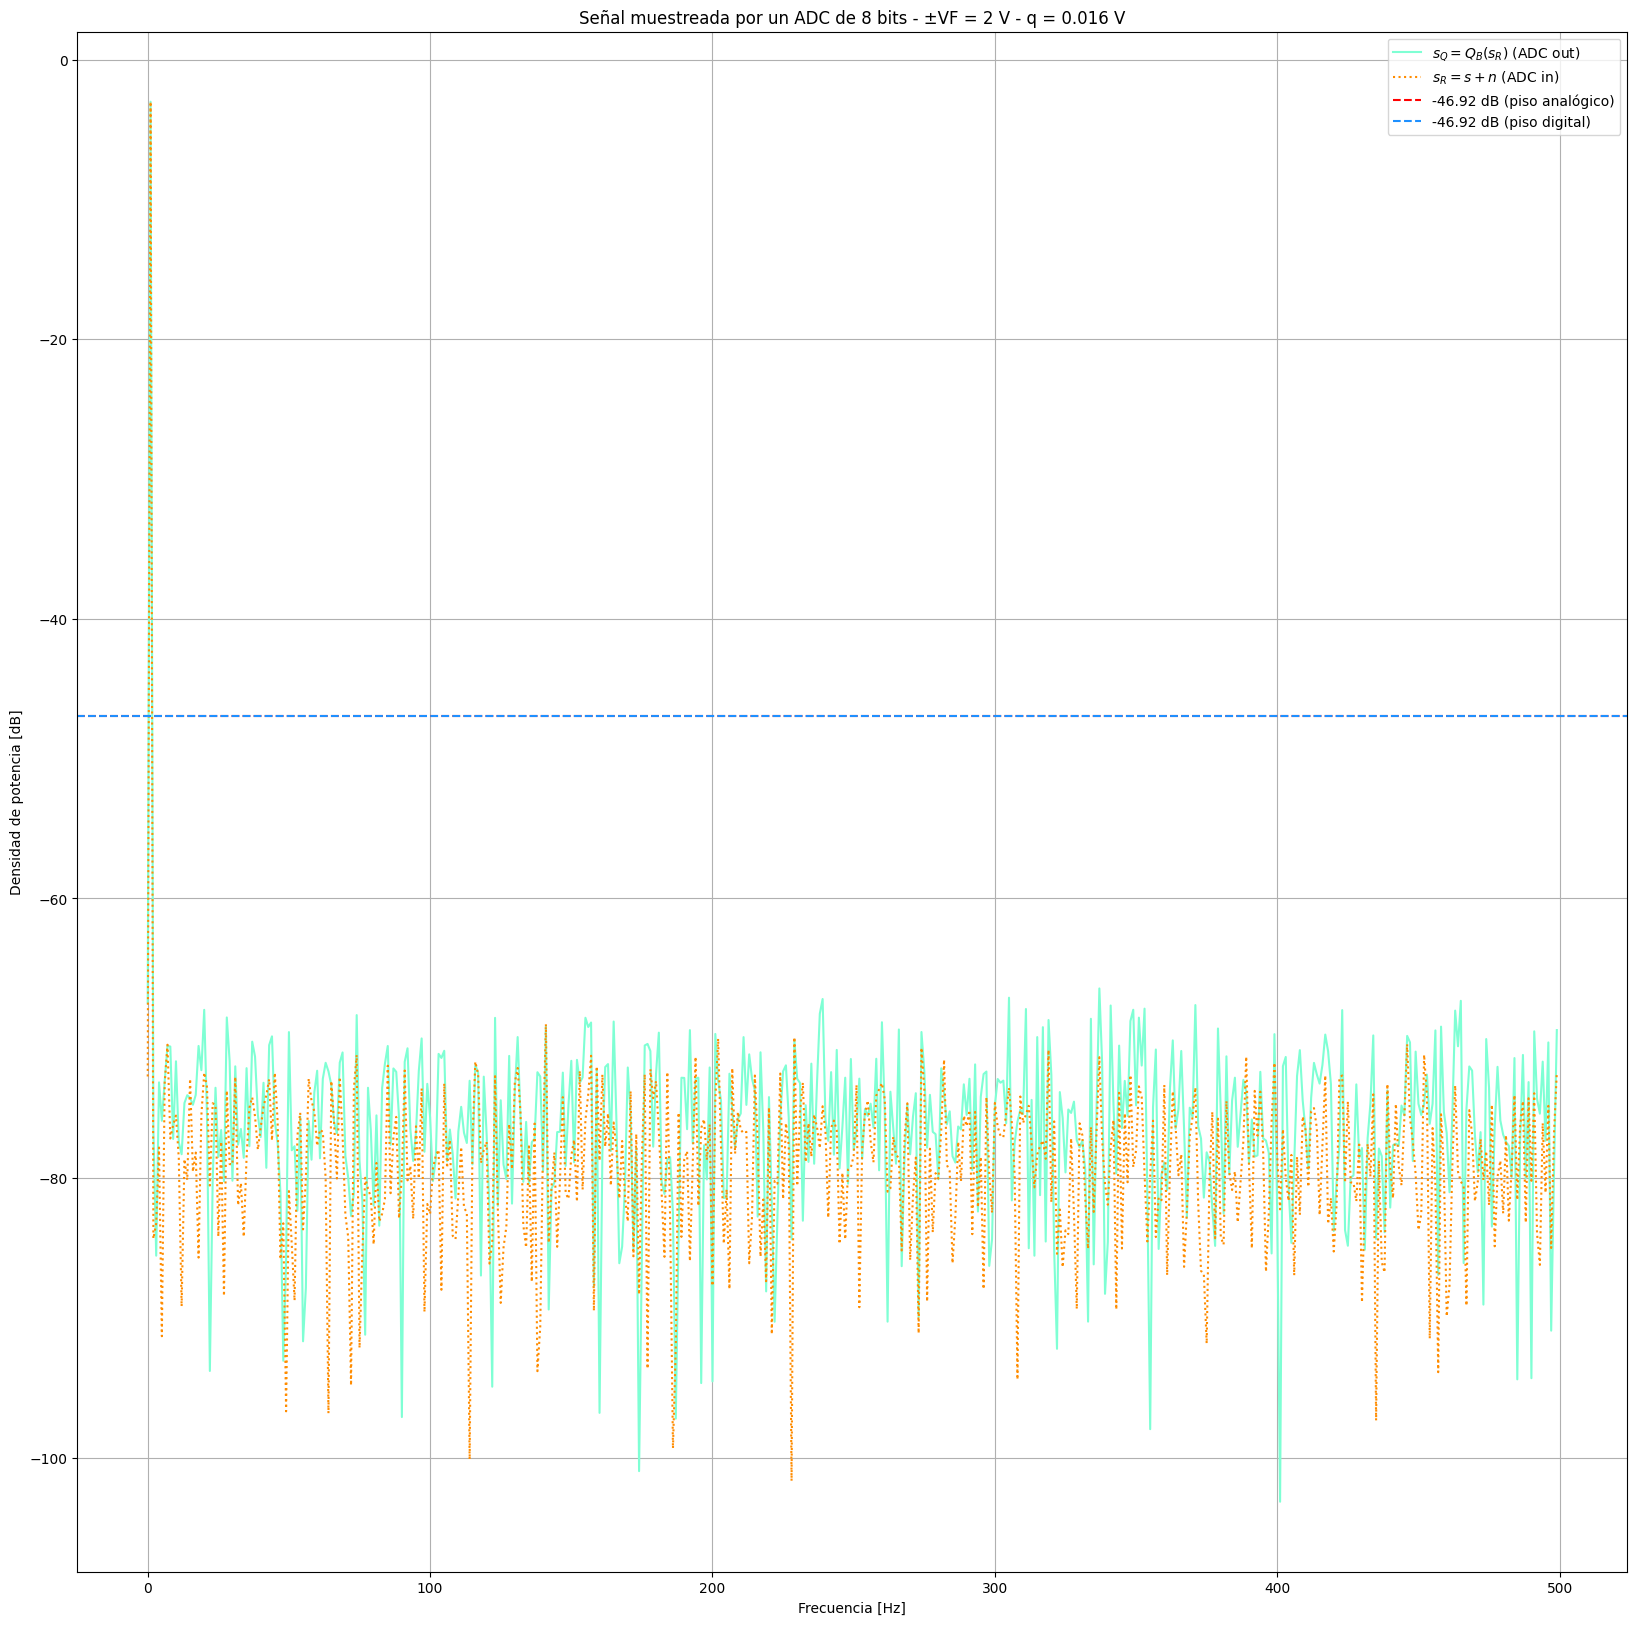

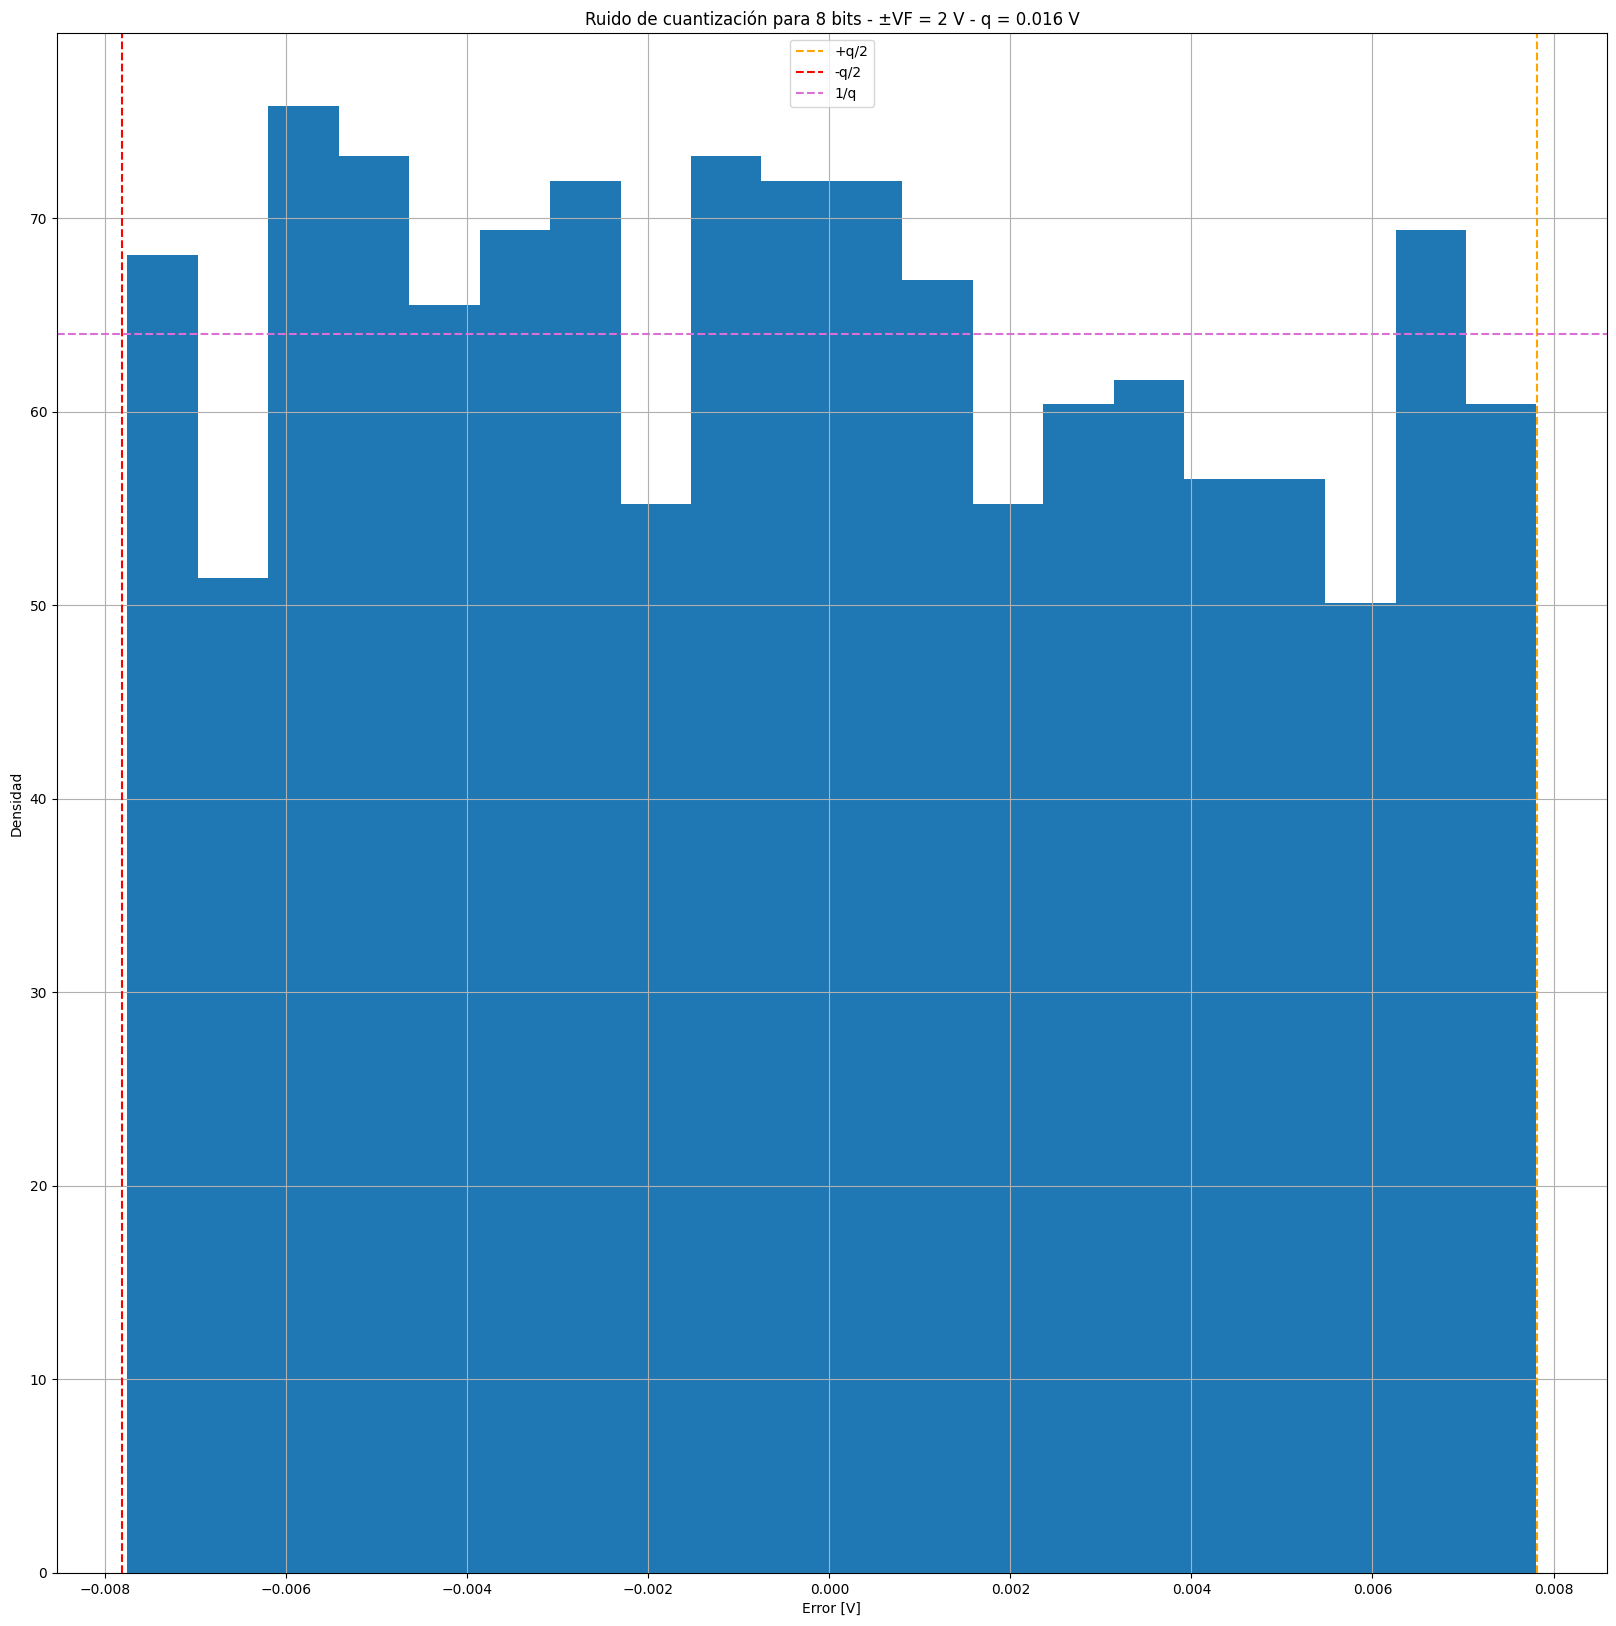

In [14]:
#%% ADC (8 bits y k = 1)
B = 8
VF = 2  # rango +-2V
q = (2*VF) / (2**B)   # paso de cuantización
Pq = (q**2) / 12      # potencia de cuantización

# Defino el ruido
kn = 1
Pn = kn * Pq
mu = 0
U_n = np.random.normal(mu, np.sqrt(Pn), n)

# Señal con ruido
sr = xx + U_n

# Cuantización (ADC)
sq = np.round(sr / q) * q

#%% FFT

N = len(xx)

# Señal pura
XX = np.fft.fft(xx)
XXmod = np.abs(XX) / N
XXmod_db = 20 * np.log10(XXmod + 1e-12)

# Señal con ruido (entrada ADC)
SR = np.fft.fft(sr)
SRmod = np.abs(SR) / N
SRmod_db = 20 * np.log10(SRmod + 1e-12)

# Señal cuantizada (salida ADC)
SQ = np.fft.fft(sq)
SQmod = np.abs(SQ) / N
SQmod_db = 20 * np.log10(SQmod + 1e-12)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, d=ts)

# Me quedo con la mitad positiva (eso es porque grafico el modulo)
mitad = N // 2
freqs = freqs[:mitad]

XXmod_db = XXmod_db[:mitad]
SRmod_db = SRmod_db[:mitad]
SQmod_db = SQmod_db[:mitad]

# Pisos teóricos
piso_analog = 10 * np.log10(Pn)
piso_digital = 10 * np.log10(Pq)

#%% Error de cuantización
e = sq - sr

#%% Graficos

# Entrada y salida del ADC
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(tt, sq, label=r'$s_Q = Q_B(s_R)$ (ADC out)')
plt.plot(tt, sr, '.', markersize=2, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt, xx, '--', label='s (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid()
plt.legend()
plt.show()


# Espectro de la FFT
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(freqs, SQmod_db, color = 'aquamarine', label=r'$s_Q = Q_B(s_R)$ (ADC out)')
# plt.plot(freqs, XXmod_db, color = 'forestgreen', label='s (analog)')
plt.plot(freqs, SRmod_db, ':', color = 'darkorange', label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analog, linestyle='--', color = 'red', label=f'{piso_analog:.2f} dB (piso analógico)')
plt.axhline(piso_digital, linestyle='--', color = 'dodgerblue', label=f'{piso_digital:.2f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF} V - q = {q:.3f} V')

plt.grid()
plt.legend()
plt.show()


# Histograma del error de cuantizacion
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.hist(e, bins=20, density=True)

plt.axvline(q/2, linestyle='--', color='orange', label='+q/2')
plt.axvline(-q/2, linestyle='--', color = 'red', label='-q/2')
plt.axhline(1/q, linestyle='--', color = 'orchid', label='1/q')

plt.title(f'Ruido de cuantización para {B} bits - ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')

plt.grid()
plt.legend()
plt.show()


16 Bits y k = 10

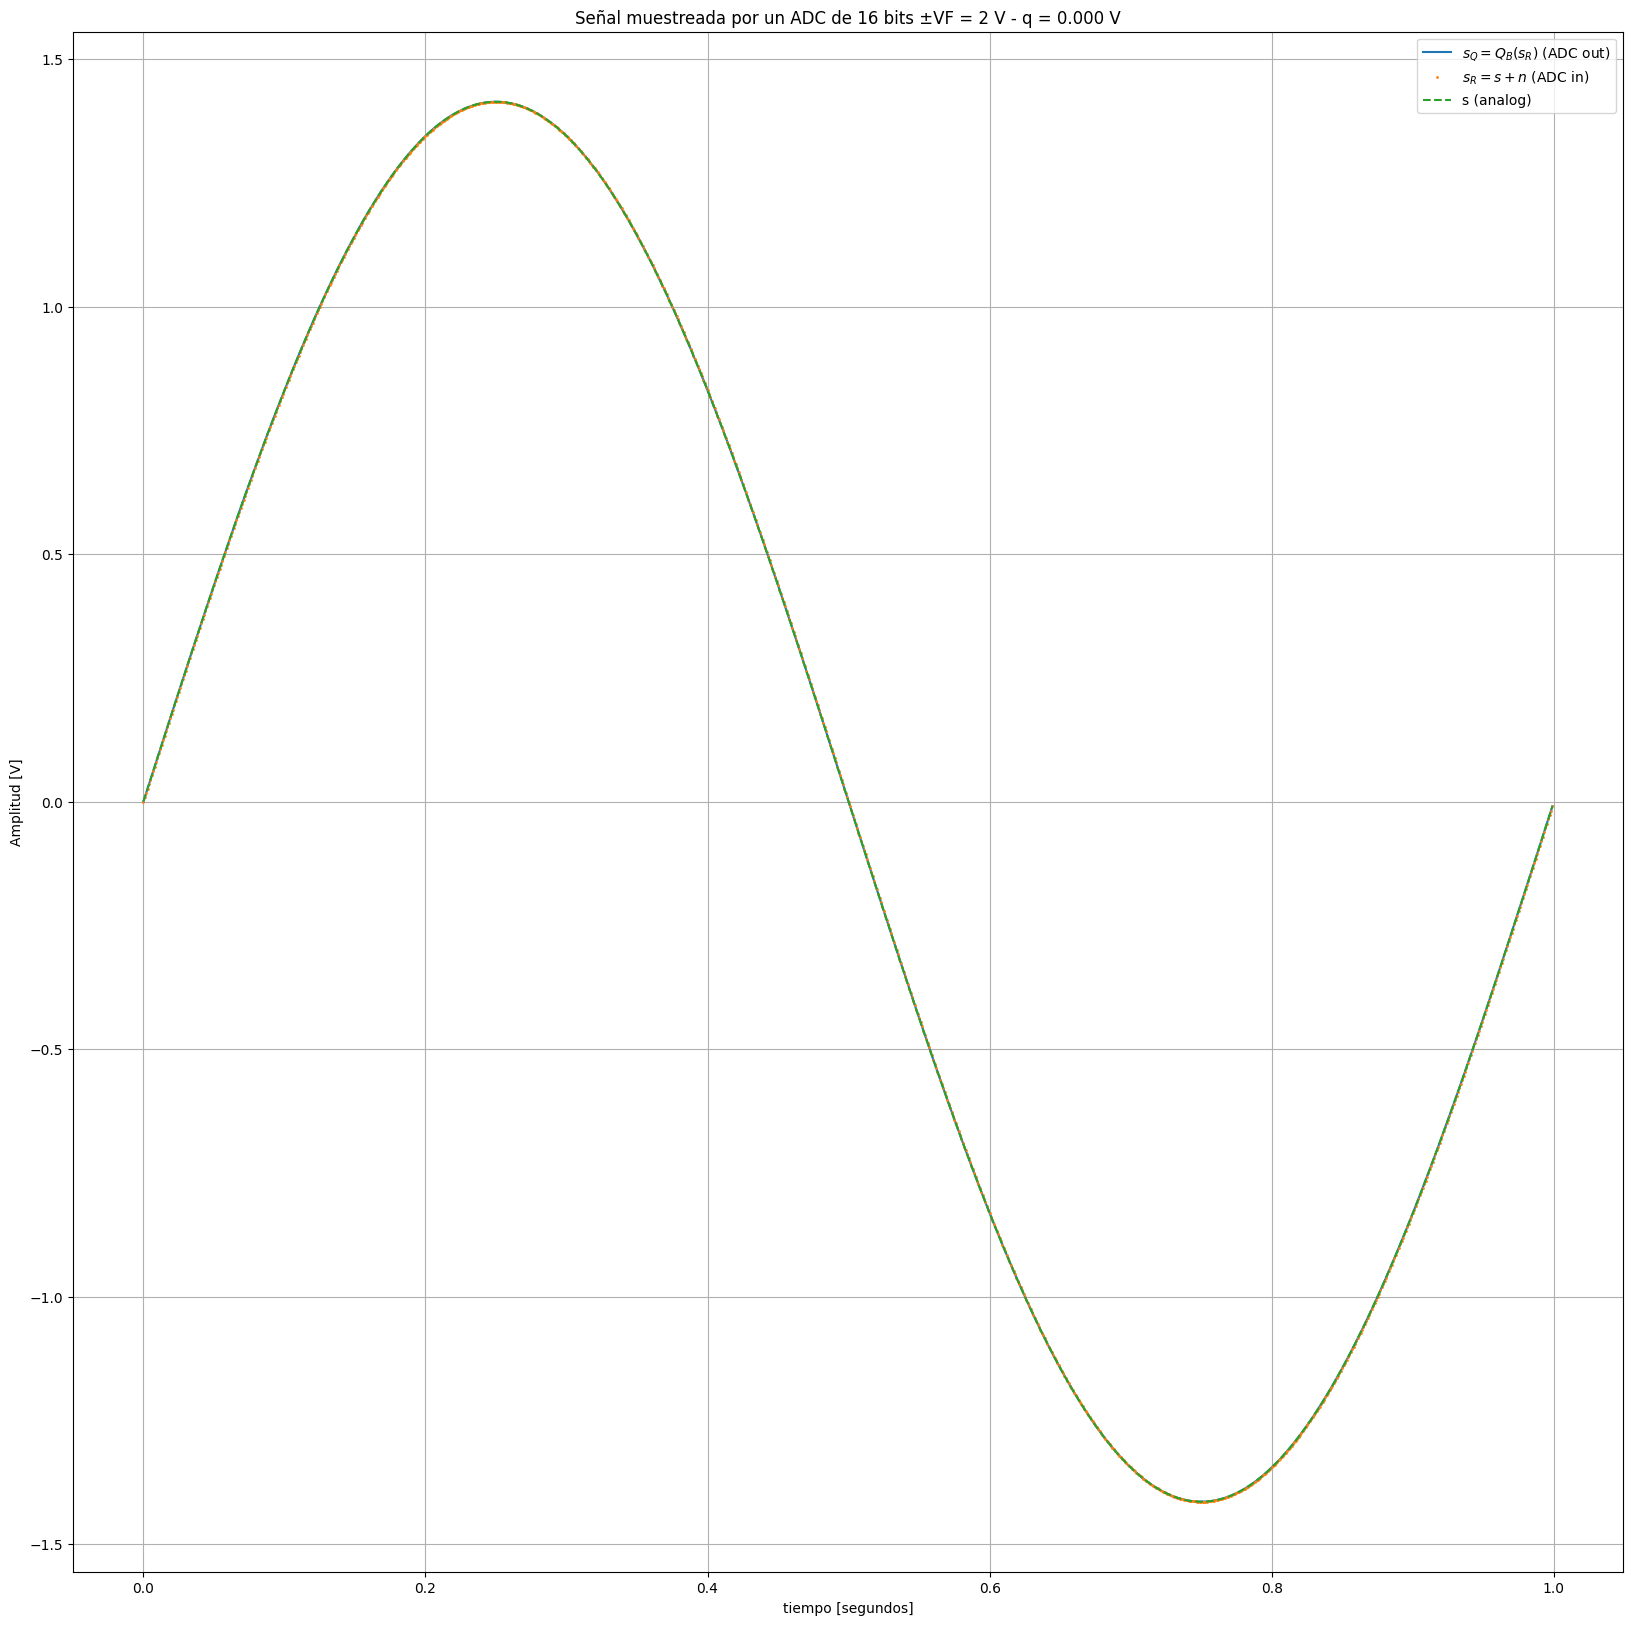

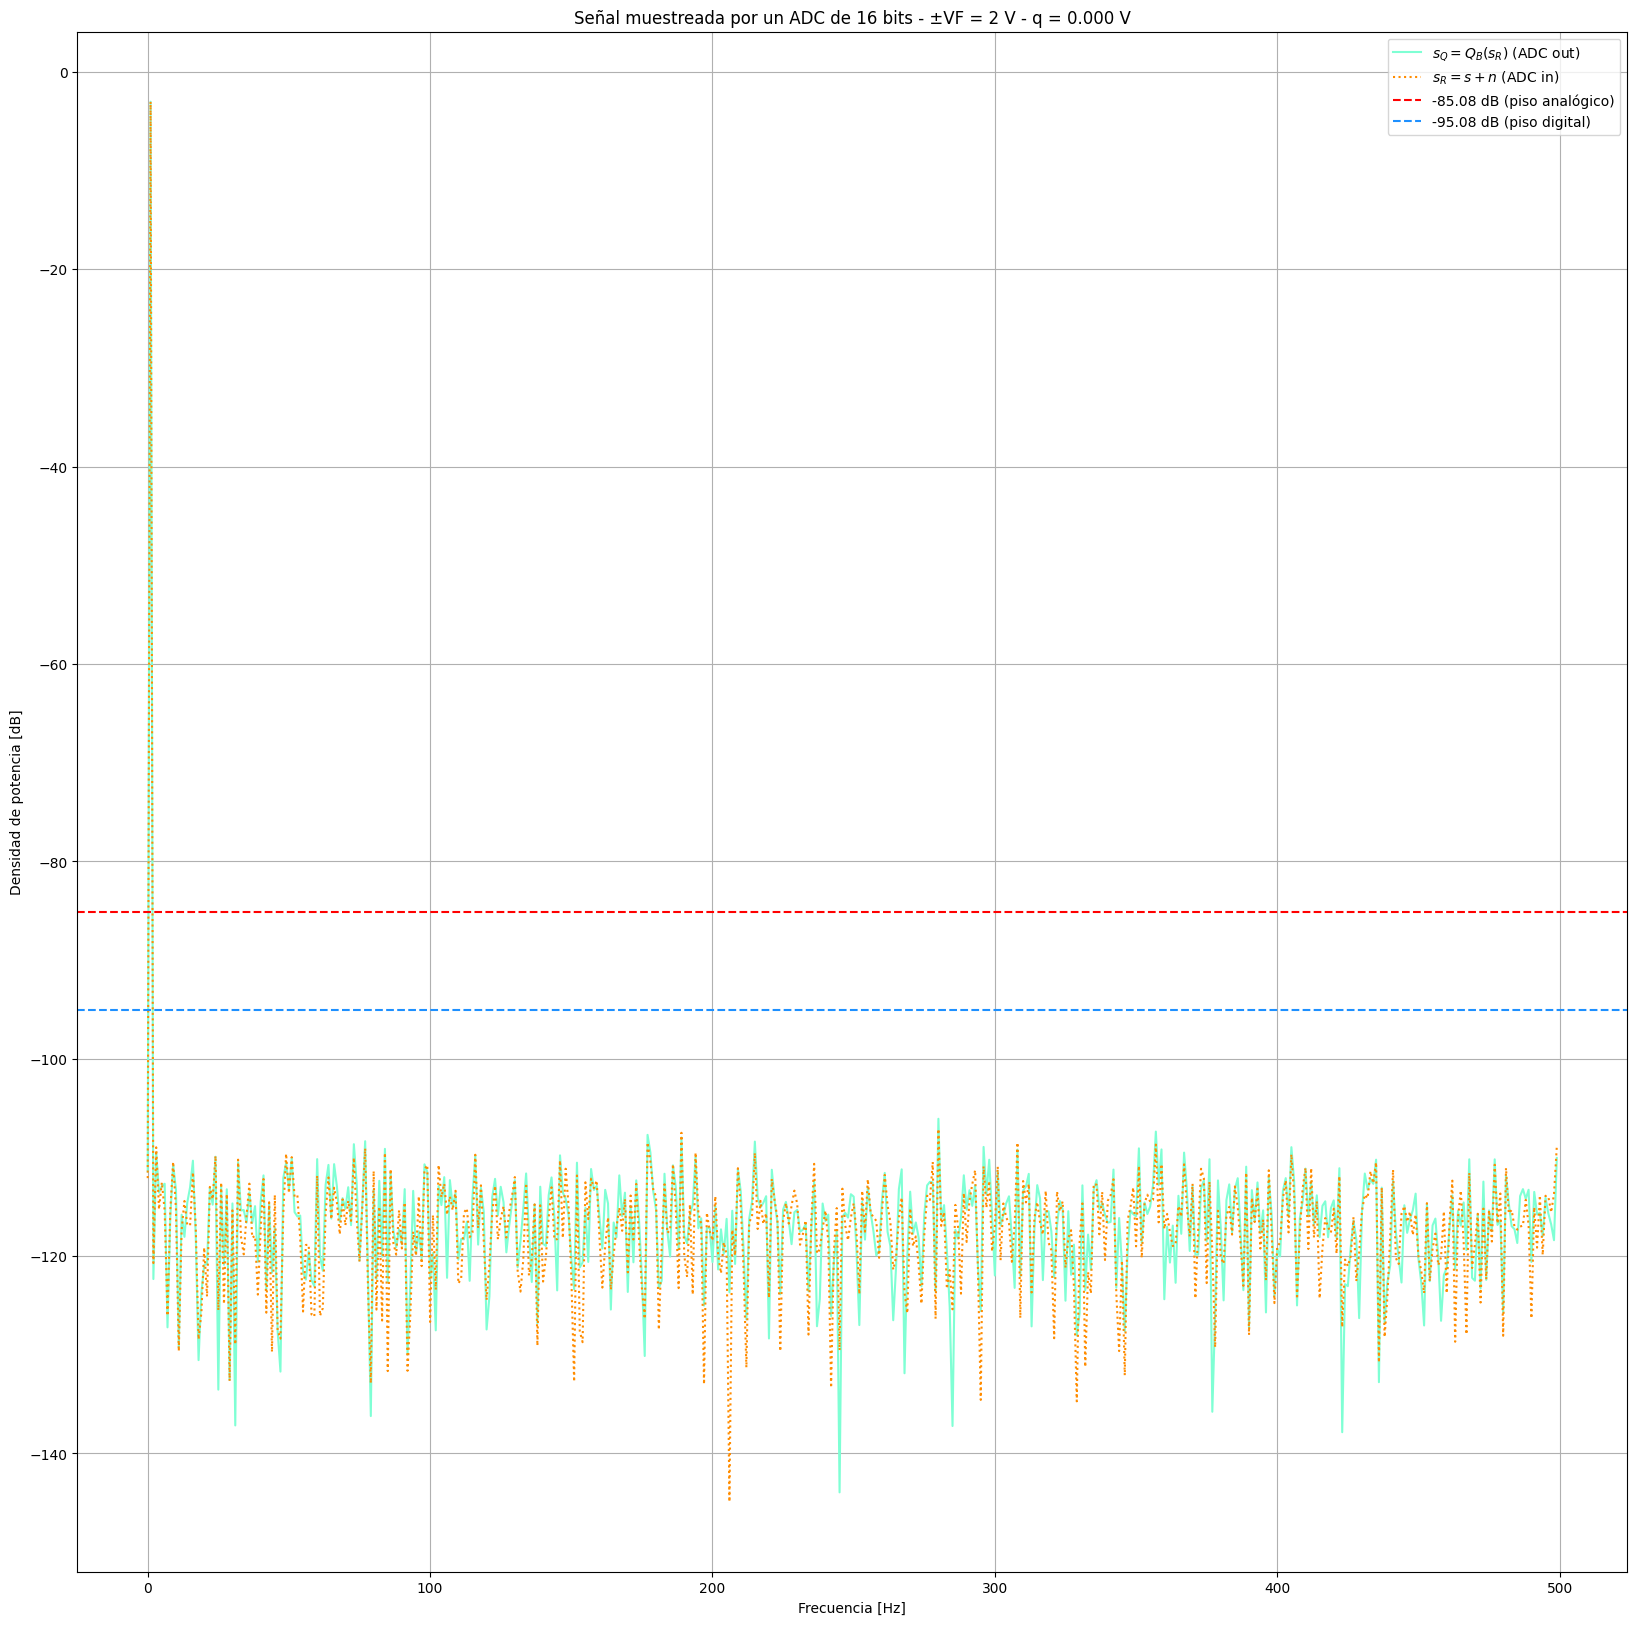

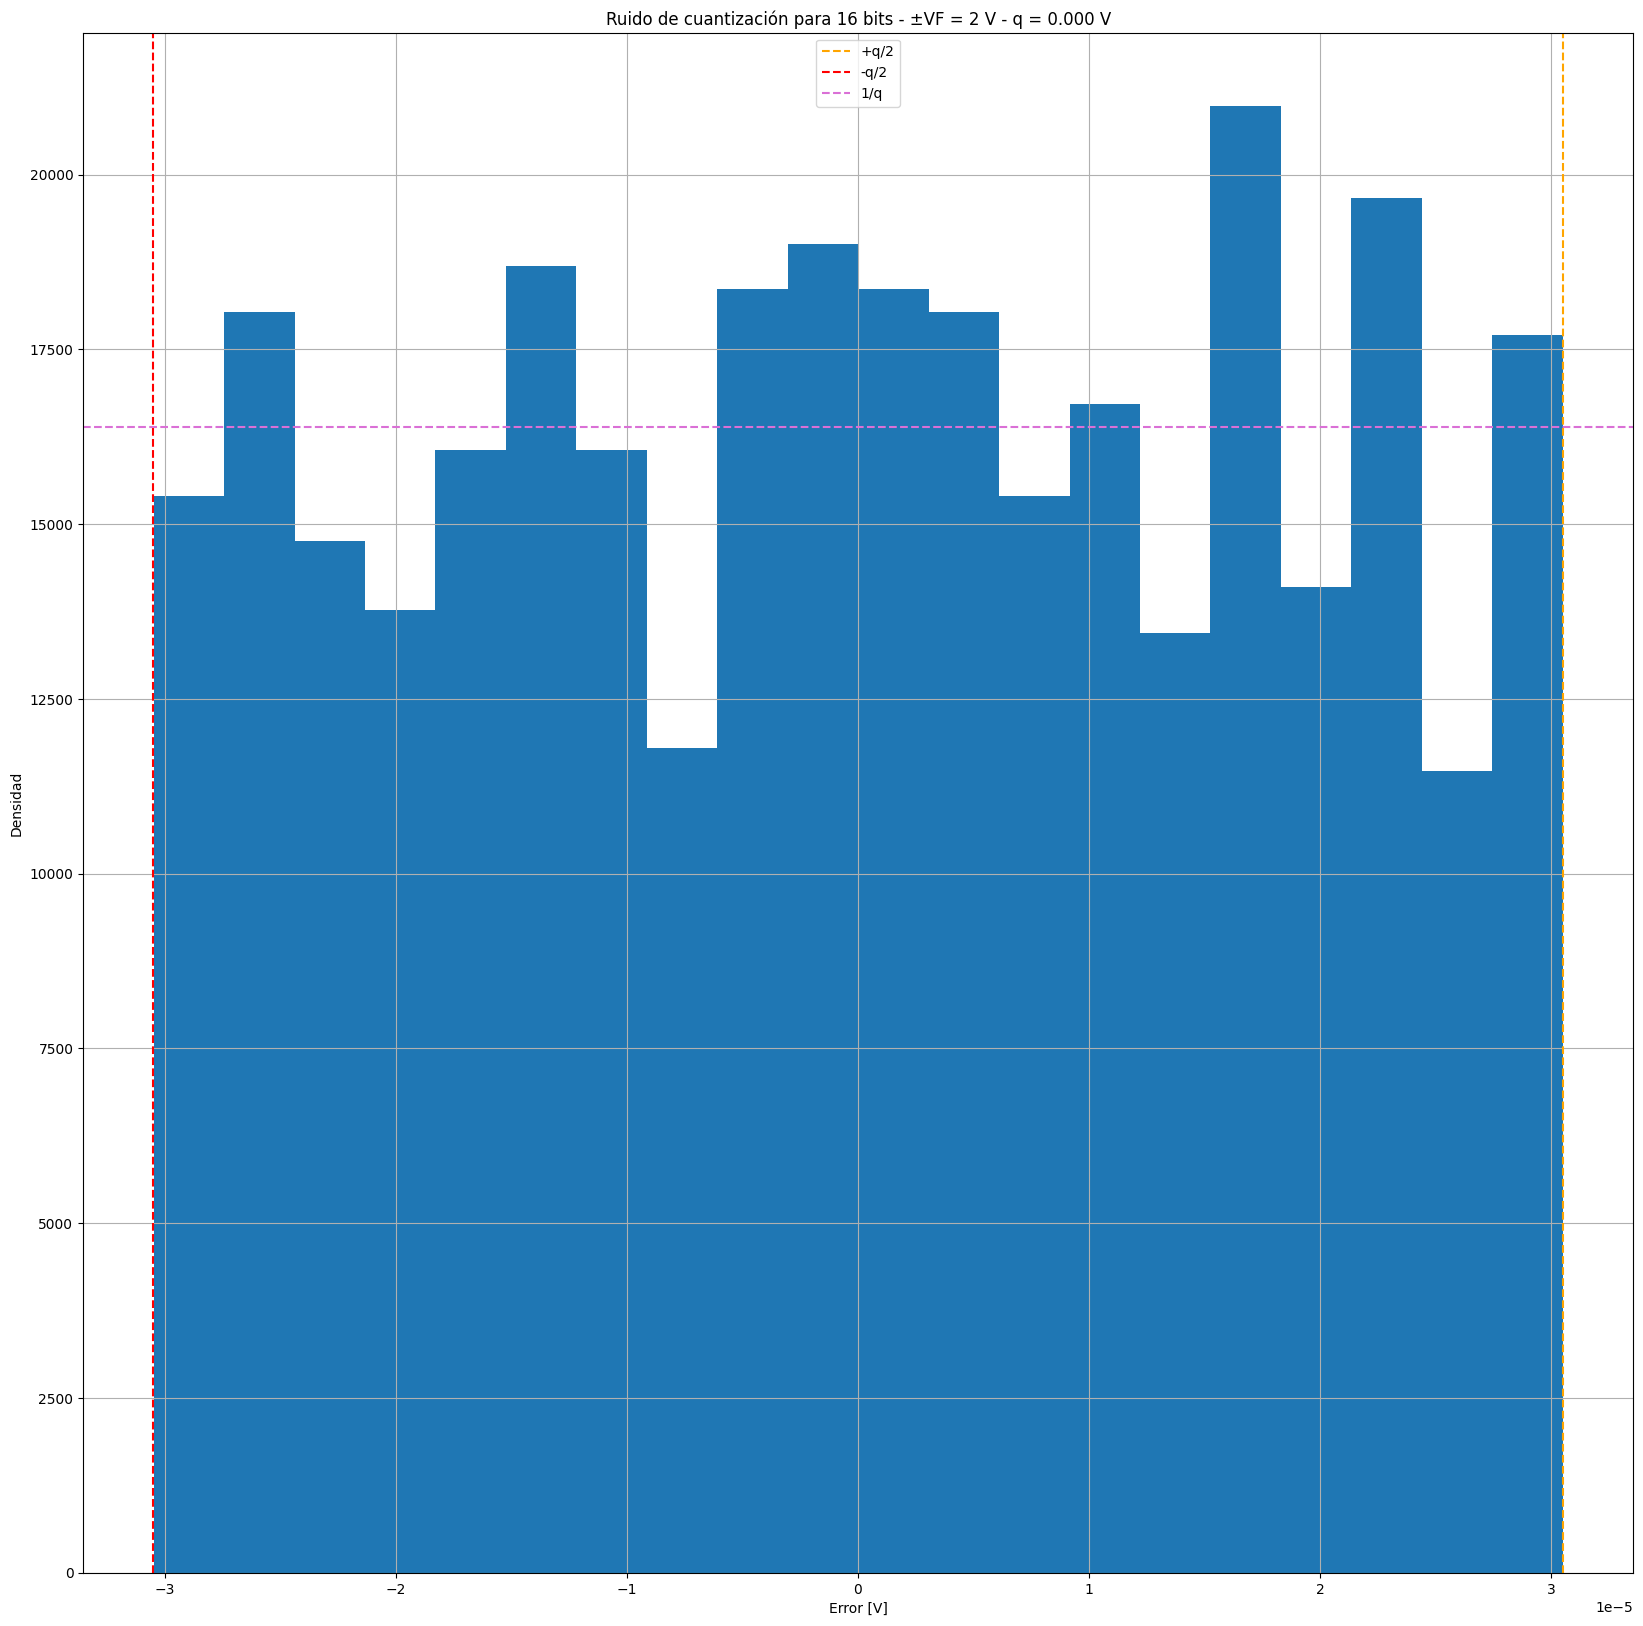

In [15]:
#%% ADC (16 bits y k = 10)
B = 16
VF = 2  # rango +-2V
q = (2*VF) / (2**B)   # paso de cuantización
Pq = (q**2) / 12      # potencia de cuantización

# Defino el ruido
kn = 10
Pn = kn * Pq
mu = 0
U_n = np.random.normal(mu, np.sqrt(Pn), n)

# Señal con ruido
sr = xx + U_n

# Cuantización (ADC)
sq = np.round(sr / q) * q

#%% FFT

N = len(xx)

# Señal pura
XX = np.fft.fft(xx)
XXmod = np.abs(XX) / N
XXmod_db = 20 * np.log10(XXmod + 1e-12)

# Señal con ruido (entrada ADC)
SR = np.fft.fft(sr)
SRmod = np.abs(SR) / N
SRmod_db = 20 * np.log10(SRmod + 1e-12)

# Señal cuantizada (salida ADC)
SQ = np.fft.fft(sq)
SQmod = np.abs(SQ) / N
SQmod_db = 20 * np.log10(SQmod + 1e-12)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, d=ts)

# Me quedo con la mitad positiva (eso es porque grafico el modulo)
mitad = N // 2
freqs = freqs[:mitad]

XXmod_db = XXmod_db[:mitad]
SRmod_db = SRmod_db[:mitad]
SQmod_db = SQmod_db[:mitad]

# Pisos teóricos
piso_analog = 10 * np.log10(Pn)
piso_digital = 10 * np.log10(Pq)

#%% Error de cuantización
e = sq - sr

#%% Graficos

# Entrada y salida del ADC
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(tt, sq, label=r'$s_Q = Q_B(s_R)$ (ADC out)')
plt.plot(tt, sr, '.', markersize=2, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt, xx, '--', label='s (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid()
plt.legend()
plt.show()


# Espectro de la FFT
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(freqs, SQmod_db, color = 'aquamarine', label=r'$s_Q = Q_B(s_R)$ (ADC out)')
# plt.plot(freqs, XXmod_db, color = 'forestgreen', label='s (analog)')
plt.plot(freqs, SRmod_db, ':', color = 'darkorange', label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analog, linestyle='--', color = 'red', label=f'{piso_analog:.2f} dB (piso analógico)')
plt.axhline(piso_digital, linestyle='--', color = 'dodgerblue', label=f'{piso_digital:.2f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF} V - q = {q:.3f} V')

plt.grid()
plt.legend()
plt.show()


# Histograma del error de cuantizacion
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.hist(e, bins=20, density=True)

plt.axvline(q/2, linestyle='--', color='orange', label='+q/2')
plt.axvline(-q/2, linestyle='--', color = 'red', label='-q/2')
plt.axhline(1/q, linestyle='--', color = 'orchid', label='1/q')

plt.title(f'Ruido de cuantización para {B} bits - ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')

plt.grid()
plt.legend()
plt.show()